In [ ]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
import os

# ----------------------------
# Fixed AB zero point for DECam z-band
ZP_AB = 30.568
# ----------------------------

# DECam FITS files
fits_files = [
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile1.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile2.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile3.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile4.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile5.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile6.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile7.fits",
]

# Input target coordinates (RA, Dec)
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# ----------------------------
# Aperture settings (pixels)
# ----------------------------
ap_radius = 7.6          # Slightly larger for DECam PSF
ann_in, ann_out = 8.0, 12.0   # Background annulus

# Output CSV
output_csv = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/fixed_target_photometry.csv"

# ----------------------------
# Convert input targets to SkyCoord
# ----------------------------
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# ----------------------------
# Main processing
# ----------------------------
all_results = []

for f in fits_files:
    print(f"Processing {f} ...")
    with fits.open(f) as hdul:
        # Find first HDU with image data
        hdu = next((h for h in hdul if h.data is not None), None)
        if hdu is None:
            print(f"  No image data found in {f}, skipping.")
            continue

        data = hdu.data.astype(float)
        header = hdu.header
        wcs = WCS(header)
        exptime = header.get('EXPTIME', np.nan)

        # Convert RA/Dec → pixel coordinates
        xpix, ypix = wcs.world_to_pixel(coords)

        # Select targets inside the image
        ny, nx = data.shape
        inside = (xpix > 0) & (xpix < nx) & (ypix > 0) & (ypix < ny)
        valid_idx = np.where(inside)[0]
        if len(valid_idx) == 0:
            print("  No targets within this tile.")
            continue

        # ----------------------------
        # Background subtraction
        # ----------------------------
        sigma_clip = SigmaClip(sigma=3.0)
        try:
            bkg_estimator = MedianBackground()
            bkg = Background2D(data, (100, 100), filter_size=(3,3),
                               sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
            data_sub = data - bkg.background
        except Exception:
            data_sub = data - np.median(data)

        # ----------------------------
        # Aperture photometry
        # ----------------------------
        positions = np.transpose([xpix[valid_idx], ypix[valid_idx]])
        apertures = CircularAperture(positions, r=ap_radius)
        annulus = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

        phot_table = aperture_photometry(data_sub, apertures)
        bkg_table = aperture_photometry(data_sub, annulus)

        # Background correction
        bkg_mean = bkg_table['aperture_sum'] / annulus.area
        flux_net = phot_table['aperture_sum'] - bkg_mean * apertures.area

        # ----------------------------
        # Compute AB magnitudes
        # ----------------------------
        for i, idx in enumerate(valid_idx):
            name = f"Target-{idx+1}"
            flux = flux_net[i]
            flux_per_sec = flux / exptime if np.isfinite(exptime) else np.nan
            mag_AB = ZP_AB - 2.5*np.log10(flux_per_sec) if flux_per_sec > 0 else np.nan

            all_results.append({
                "filename": os.path.basename(f),
                "target": name,
                "RA": coords[idx].ra.deg,
                "Dec": coords[idx].dec.deg,
                "x_pix": xpix[idx],
                "y_pix": ypix[idx],
                "flux_counts": flux,
                "flux_per_sec": flux_per_sec,
                "mag_AB": mag_AB,
                "EXPTIME": exptime,
                "ZP_AB": ZP_AB
            })

# ----------------------------
# Save results
# ----------------------------
if all_results:
    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False)
    print(f"\nSaved photometry results to {output_csv}")
else:
    print("No valid detections found in any tiles.")


Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile1.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile2.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile3.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile4.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile5.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile6.fits
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile7.fits

Saved photometry results to /Users/aishwarya/Documents/Lyman_alpha/z_unpack/fixed_target_photometry_no_sky.csv


In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip, mad_std
import os

# ----------------------------
# Fixed AB zero point for DECam z-band
ZP_AB = 30.568
# ----------------------------

# DECam FITS files
fits_files = [
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile1.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile2.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile3.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile4.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile5.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile6.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile7.fits",
]

# Input target coordinates (same as before)
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]


# ----------------------------
# REVISED Aperture settings (pixels)
# ----------------------------
ap_radius = 4.0          # Smaller aperture for DECam (≈1" radius)
ann_in, ann_out = 6.0, 10.0   # Wider background annulus

# Output CSV
output_csv = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/fixed_target_photometry.csv"

# ----------------------------
# Convert input targets to SkyCoord
# ----------------------------
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# ----------------------------
# Main processing - IMPROVED
# ----------------------------
all_results = []

for f in fits_files:
    print(f"Processing {f} ...")
    try:
        with fits.open(f) as hdul:
            # Find first HDU with image data
            hdu = next((h for h in hdul if h.data is not None), None)
            if hdu is None:
                print(f"  No image data found in {f}, skipping.")
                continue

            data = hdu.data.astype(float)
            header = hdu.header
            wcs = WCS(header)
            exptime = header.get('EXPTIME', np.nan)
            
            # Get pixel scale for verification
            try:
                pixscale = np.sqrt(wcs.proj_plane_pixel_area()).to(u.arcsec).value
                print(f"  Pixel scale: {pixscale:.3f} arcsec/pixel")
            except:
                pixscale = 0.263  # Default DECam pixel scale

            # Convert RA/Dec → pixel coordinates
            xpix, ypix = wcs.world_to_pixel(coords)

            # Select targets inside the image with buffer
            ny, nx = data.shape
            buffer = 20  # pixels buffer from edges
            inside = (xpix > buffer) & (xpix < nx - buffer) & (ypix > buffer) & (ypix < ny - buffer)
            valid_idx = np.where(inside)[0]
            
            if len(valid_idx) == 0:
                print("  No targets within this tile.")
                continue

            print(f"  Found {len(valid_idx)} targets in image")

            # ----------------------------
            # Improved Background subtraction
            # ----------------------------
            sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
            try:
                bkg_estimator = MedianBackground()
                bkg = Background2D(data, (50, 50), filter_size=(3, 3),
                                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
                data_sub = data - bkg.background
                bkg_rms = mad_std(data_sub)
                print(f"  Background RMS: {bkg_rms:.3f} counts")
            except Exception as e:
                print(f"  Background2D failed: {e}, using simple median")
                bkg_level = np.median(data)
                data_sub = data - bkg_level
                bkg_rms = mad_std(data_sub)

            # ----------------------------
            # Aperture photometry with error estimation
            # ----------------------------
            positions = np.transpose([xpix[valid_idx], ypix[valid_idx]])
            apertures = CircularAperture(positions, r=ap_radius)
            annulus = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

            # Perform photometry
            phot_table = aperture_photometry(data_sub, apertures)
            bkg_table = aperture_photometry(data_sub, annulus)

            # Background correction with area normalization
            bkg_area = annulus.area
            bkg_mean = bkg_table['aperture_sum'] / bkg_area
            flux_net = phot_table['aperture_sum'] - (bkg_mean * apertures.area)
            
            # Estimate errors
            flux_err = np.sqrt(phot_table['aperture_sum'] + (apertures.area * (bkg_rms**2)))

            # ----------------------------
            # Quality checks and magnitude calculation
            # ----------------------------
            for i, idx in enumerate(valid_idx):
                name = f"Target-{idx+1}"
                flux = flux_net[i]
                flux_err_i = flux_err[i]
                
                # Quality flags
                snr = flux / flux_err_i if flux_err_i > 0 else 0
                in_annulus = bkg_table['aperture_sum'][i] / annulus.area
                
                # Calculate magnitude with safety checks
                if np.isfinite(exptime) and exptime > 0:
                    flux_per_sec = flux / exptime
                    if flux_per_sec > 0 and snr > 1:
                        mag_AB = ZP_AB - 2.5 * np.log10(flux_per_sec)
                        mag_err = 1.0857 * (flux_err_i / flux)  # approximate magnitude error
                    else:
                        mag_AB = np.nan
                        mag_err = np.nan
                else:
                    flux_per_sec = np.nan
                    mag_AB = np.nan
                    mag_err = np.nan

                all_results.append({
                    "filename": os.path.basename(f),
                    "target": name,
                    "RA": coords[idx].ra.deg,
                    "Dec": coords[idx].dec.deg,
                    "x_pix": xpix[idx],
                    "y_pix": ypix[idx],
                    "flux_counts": flux,
                    "flux_err": flux_err_i,
                    "flux_per_sec": flux_per_sec,
                    "mag_AB": mag_AB,
                    "mag_err": mag_err,
                    "SNR": snr,
                    "EXPTIME": exptime,
                    "ZP_AB": ZP_AB,
                    "bkg_level": bkg_mean[i],
                    "bkg_rms": bkg_rms,
                    "pixel_scale": pixscale
                })
                
    except Exception as e:
        print(f"  ERROR processing {f}: {e}")
        continue

# ----------------------------
# Save results with quality summary
# ----------------------------
if all_results:
    df = pd.DataFrame(all_results)
    
    # Add quality summary
    valid_mags = df['mag_AB'].notna()
    print(f"\nPhotometry Summary:")
    print(f"Total measurements: {len(df)}")
    print(f"Valid magnitudes: {valid_mags.sum()}")
    if valid_mags.any():
        print(f"Magnitude range: {df.loc[valid_mags, 'mag_AB'].min():.2f} to {df.loc[valid_mags, 'mag_AB'].max():.2f}")
        print(f"Median SNR: {df['SNR'].median():.2f}")
    
    df.to_csv(output_csv, index=False)
    print(f"\nSaved photometry results to {output_csv}")
else:
    print("No valid detections found in any tiles.")

Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile1.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 3 targets in image
  Background RMS: 0.273 counts
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile2.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 7 targets in image
  Background RMS: 1.486 counts
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile3.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 1 targets in image
  Background RMS: 0.277 counts
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile4.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 4 targets in image
  Background RMS: 1.282 counts
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile5.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 4 targets in image
  Background RMS: 1.585 counts
Processing /Users/aishwarya/Documents/Lyman_alpha/z_unpack/Fitz_tile6.fits ...
  Pixel scale: 0.270 arcsec/pixel
  Found 4 targets in image
  Bac

=== FLUX ANALYSIS ===
Total measurements: 27
Mean flux: 129.32 ± 330.42
Flux range: 14.81 to 1775.83
Median SNR: 5.12
Measurements with SNR < 3: 1/27
Negative fluxes: 0/27
Large errors (err > flux): 0/27


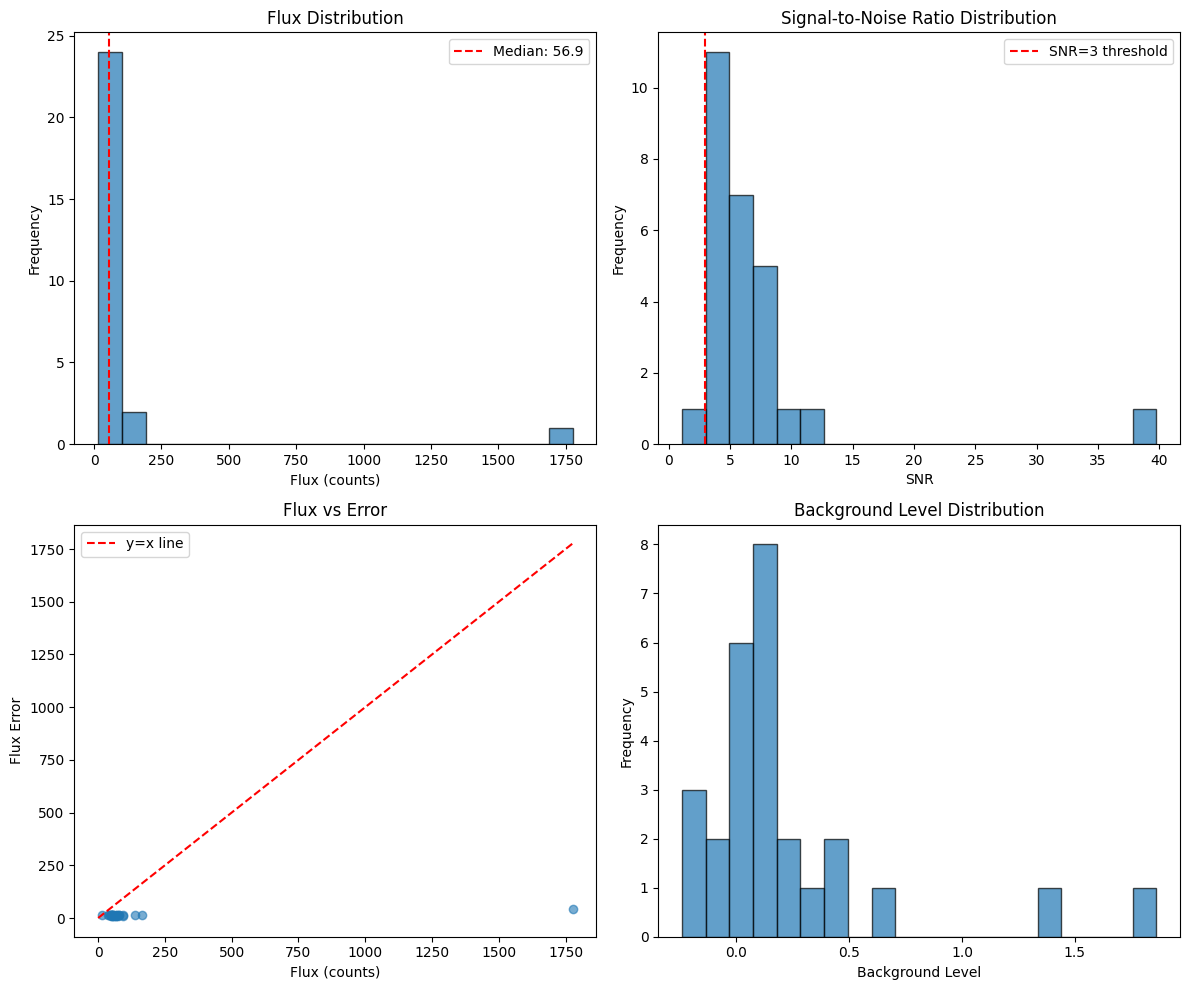

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Analyze your current results
def analyze_flux_results(df):
    print("=== FLUX ANALYSIS ===")
    print(f"Total measurements: {len(df)}")
    print(f"Mean flux: {df['flux_counts'].mean():.2f} ± {df['flux_counts'].std():.2f}")
    print(f"Flux range: {df['flux_counts'].min():.2f} to {df['flux_counts'].max():.2f}")
    print(f"Median SNR: {df['SNR'].median():.2f}")
    
    # Count problematic measurements
    low_snr = (df['SNR'] < 3).sum()
    negative_flux = (df['flux_counts'] < 0).sum()
    high_error = (df['flux_err'] > df['flux_counts']).sum()
    
    print(f"Measurements with SNR < 3: {low_snr}/{len(df)}")
    print(f"Negative fluxes: {negative_flux}/{len(df)}")
    print(f"Large errors (err > flux): {high_error}/{len(df)}")
    
    # Plot distributions
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Flux distribution
    axes[0,0].hist(df['flux_counts'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,0].set_xlabel('Flux (counts)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Flux Distribution')
    axes[0,0].axvline(df['flux_counts'].median(), color='red', linestyle='--', label=f'Median: {df["flux_counts"].median():.1f}')
    axes[0,0].legend()
    
    # SNR distribution
    axes[0,1].hist(df['SNR'], bins=20, alpha=0.7, edgecolor='black')
    axes[0,1].set_xlabel('SNR')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Signal-to-Noise Ratio Distribution')
    axes[0,1].axvline(3, color='red', linestyle='--', label='SNR=3 threshold')
    axes[0,1].legend()
    
    # Flux vs Error
    axes[1,0].scatter(df['flux_counts'], df['flux_err'], alpha=0.6)
    axes[1,0].plot([0, df['flux_counts'].max()], [0, df['flux_counts'].max()], 'r--', label='y=x line')
    axes[1,0].set_xlabel('Flux (counts)')
    axes[1,0].set_ylabel('Flux Error')
    axes[1,0].set_title('Flux vs Error')
    axes[1,0].legend()
    
    # Background level distribution
    axes[1,1].hist(df['bkg_level'], bins=20, alpha=0.7, edgecolor='black')
    axes[1,1].set_xlabel('Background Level')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Background Level Distribution')
    
    plt.tight_layout()
    plt.show()

# Run analysis on your data
analyze_flux_results(df)

Starting faint source photometry...
Output directory: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/

Processing Fitz_tile1.fits ...
  Image shape: (8979, 9862)
  Exposure time: 1.0s
  Image median: 436.97, robust std: 0.26
  Found 3 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median
  Target cutout statistics:
    Target 2: pos=(8828.2, 537.0), median=0.29, std=1.84
    Target 8: pos=(4738.8, 7424.0), median=0.20, std=1.70
    Target 12: pos=(4420.0, 8795.0), median=-0.02, std=1.79

Processing Fitz_tile2.fits ...
  Image shape: (8979, 9862)
  Exposure time: 1.0s
  Image median: 436.96, robust std: 1.42
  Found 7 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median
  Target cutout statistics:
    Target 3: pos=(2464.0, 738.0), median=0.17, std=2.22
    Target 4: pos=(1508.9, 2416.0), median=0.16, std=1.65
    Target 5: pos=(5448.8, 

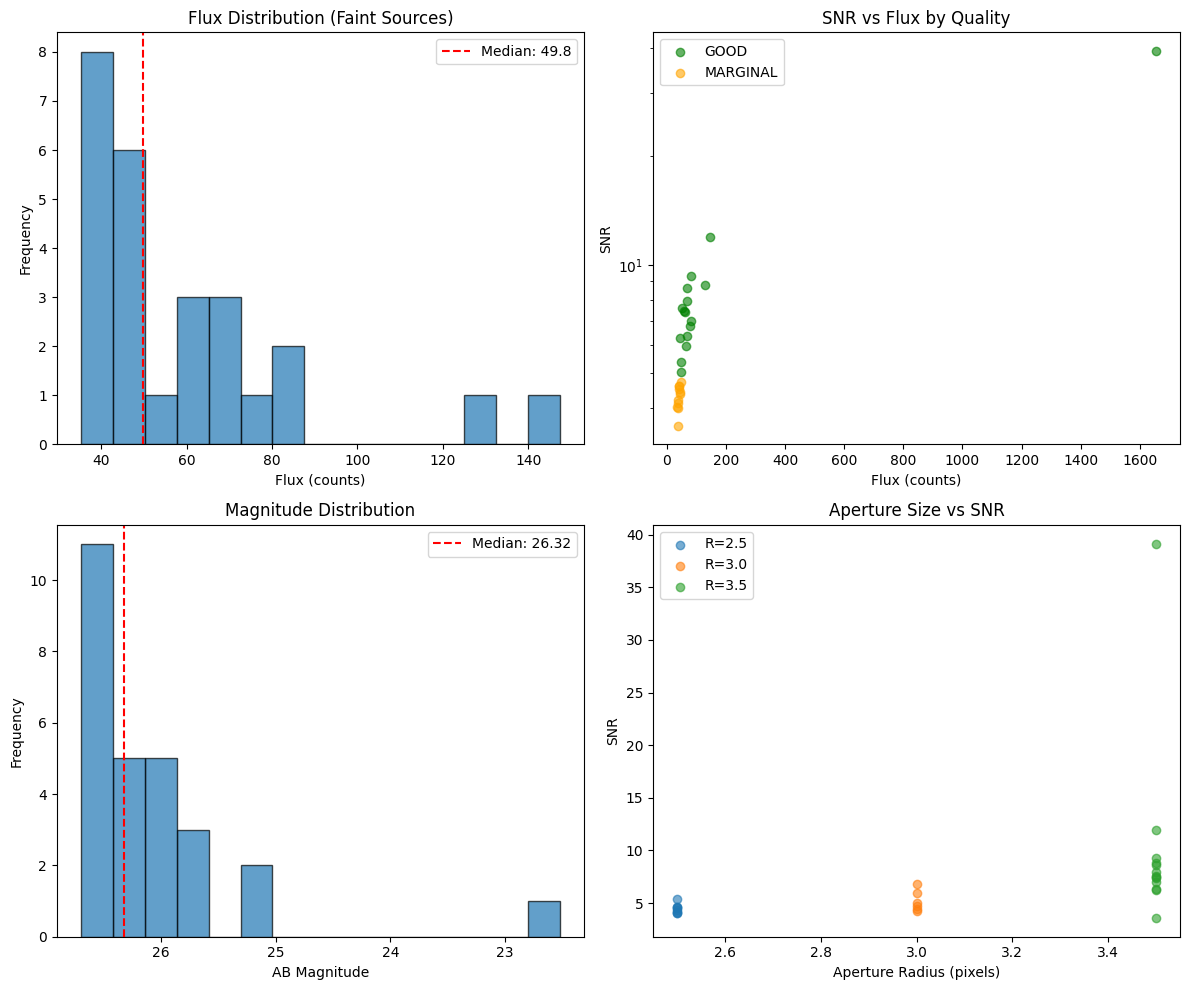


=== FILES SAVED ===
Best photometry results: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv
All aperture trials: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/all_apertures_photometry.csv
Diagnostic plots: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/photometry_diagnostics.png
Summary report: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/photometry_summary.txt

Photometry complete!


In [4]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip, mad_std
import matplotlib.pyplot as plt
import os

# ----------------------------
# Configuration
# ----------------------------
ZP_AB = 30.568  # Fixed AB zero point for DECam z-band

# Set output directory to same folder as input files
input_dir = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/"
output_dir = input_dir  # Save everything to same folder

# DECam FITS files
fits_files = [
    os.path.join(input_dir, "Fitz_tile1.fits"),
    os.path.join(input_dir, "Fitz_tile2.fits"),
    os.path.join(input_dir, "Fitz_tile3.fits"),
    os.path.join(input_dir, "Fitz_tile4.fits"),
    os.path.join(input_dir, "Fitz_tile5.fits"),
    os.path.join(input_dir, "Fitz_tile6.fits"),
    os.path.join(input_dir, "Fitz_tile7.fits"),
]

# Input target coordinates
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# Output files
output_csv = os.path.join(output_dir, "faint_source_photometry_results.csv")
all_apertures_csv = os.path.join(output_dir, "all_apertures_photometry.csv")
diagnostics_plot = os.path.join(output_dir, "photometry_diagnostics.png")
summary_report = os.path.join(output_dir, "photometry_summary.txt")

# ----------------------------
# Convert input targets to SkyCoord
# ----------------------------
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# ----------------------------
# Photometry Functions
# ----------------------------

def create_faint_source_plots(df, save_path):
    """Create diagnostic plots optimized for faint sources"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Flux distribution (focus on faint end)
    faint_fluxes = df[df['flux_counts'] < 500]['flux_counts']
    axes[0,0].hist(faint_fluxes, bins=15, alpha=0.7, edgecolor='black')
    axes[0,0].set_xlabel('Flux (counts)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Flux Distribution (Faint Sources)')
    if len(faint_fluxes) > 0:
        axes[0,0].axvline(faint_fluxes.median(), color='red', linestyle='--', 
                         label=f'Median: {faint_fluxes.median():.1f}')
    axes[0,0].legend()
    
    # SNR by quality flag
    quality_colors = {'GOOD': 'green', 'MARGINAL': 'orange', 'POOR': 'red'}
    for quality in df['quality_flag'].unique():
        quality_data = df[df['quality_flag'] == quality]
        if len(quality_data) > 0:
            axes[0,1].scatter(quality_data['flux_counts'], quality_data['SNR'], 
                             alpha=0.6, label=quality, c=quality_colors.get(quality, 'blue'))
    axes[0,1].set_xlabel('Flux (counts)')
    axes[0,1].set_ylabel('SNR')
    axes[0,1].set_title('SNR vs Flux by Quality')
    axes[0,1].legend()
    axes[0,1].set_yscale('log')
    
    # Magnitude distribution
    valid_mags = df[df['mag_AB'].notna()]['mag_AB']
    if len(valid_mags) > 0:
        axes[1,0].hist(valid_mags, bins=15, alpha=0.7, edgecolor='black')
        axes[1,0].set_xlabel('AB Magnitude')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Magnitude Distribution')
        axes[1,0].axvline(valid_mags.median(), color='red', linestyle='--',
                         label=f'Median: {valid_mags.median():.2f}')
        axes[1,0].legend()
        axes[1,0].invert_xaxis()  # Brighter to the right
    else:
        axes[1,0].text(0.5, 0.5, 'No valid magnitudes', ha='center', va='center', 
                      transform=axes[1,0].transAxes)
    
    # Aperture size vs SNR
    for ap_radius in sorted(df['aperture_radius'].unique()):
        ap_data = df[df['aperture_radius'] == ap_radius]
        if len(ap_data) > 0:
            axes[1,1].scatter(ap_data['aperture_radius'], ap_data['SNR'], alpha=0.6, 
                             label=f'R={ap_radius}')
    axes[1,1].set_xlabel('Aperture Radius (pixels)')
    axes[1,1].set_ylabel('SNR')
    axes[1,1].set_title('Aperture Size vs SNR')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def perform_faint_source_photometry(fits_files, coords):
    """
    Optimized photometry for very faint sources
    """
    
    # Smaller apertures for faint sources to maximize SNR
    aperture_radii = [2.5, 3.0, 3.5]  # Smaller apertures for faint sources
    annulus_radii = [(6.0, 10.0), (8.0, 12.0)]  # Close but clean annulus
    
    all_results = []
    
    for f in fits_files:
        print(f"\nProcessing {os.path.basename(f)} ...")
        
        try:
            with fits.open(f) as hdul:
                # Find first HDU with image data
                hdu = next((h for h in hdul if h.data is not None and len(h.data.shape) == 2), None)
                if hdu is None:
                    print(f"  No 2D image data found, skipping.")
                    continue

                data = hdu.data.astype(float)
                header = hdu.header
                wcs = WCS(header)
                exptime = header.get('EXPTIME', 1.0)
                
                print(f"  Image shape: {data.shape}")
                print(f"  Exposure time: {exptime:.1f}s")
                
                # Get robust image statistics
                sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
                clipped_data = sigma_clip(data)
                image_median = np.ma.median(clipped_data)
                image_std = mad_std(clipped_data)
                print(f"  Image median: {image_median:.2f}, robust std: {image_std:.2f}")

                # Convert RA/Dec → pixel coordinates
                xpix, ypix = wcs.world_to_pixel(coords)

                # Select targets inside the image with buffer
                ny, nx = data.shape
                buffer = 30
                inside = (xpix > buffer) & (xpix < nx - buffer) & (ypix > buffer) & (ypix < ny - buffer)
                valid_idx = np.where(inside)[0]
                
                if len(valid_idx) == 0:
                    print("  No targets within this tile.")
                    continue

                print(f"  Found {len(valid_idx)} targets in image")

                # ----------------------------
                # Conservative Background subtraction for faint sources
                # ----------------------------
                try:
                    # Use larger boxes for better background estimation
                    sigma_clip = SigmaClip(sigma=2.5, maxiters=5)  # Less aggressive
                    bkg_estimator = MedianBackground()
                    bkg = Background2D(data, (512, 512), filter_size=(7, 7),
                                       sigma_clip=sigma_clip, bkg_estimator=bkg_estimator,
                                       exclude_percentile=5.0)  # Exclude only brightest 5%
                    data_sub = data - bkg.background
                    bkg_rms = bkg.background_rms
                    print(f"  Background RMS: {bkg_rms:.3f} counts")
                except Exception as e:
                    print(f"  Background2D failed: {e}, using sigma-clipped median")
                    bkg_level = np.ma.median(sigma_clip(data))
                    data_sub = data - bkg_level
                    bkg_rms = mad_std(sigma_clip(data))

                # ----------------------------
                # Create cutouts around each target for inspection
                # ----------------------------
                positions = np.transpose([xpix[valid_idx], ypix[valid_idx]])
                cutout_size = 20  # pixels
                
                print("  Target cutout statistics:")
                for i, (x, y) in enumerate(positions):
                    x_int, y_int = int(round(x)), int(round(y))
                    x_slice = slice(max(0, x_int-cutout_size), min(nx, x_int+cutout_size+1))
                    y_slice = slice(max(0, y_int-cutout_size), min(ny, y_int+cutout_size+1))
                    cutout = data_sub[y_slice, x_slice]
                    cutout_median = np.median(cutout)
                    cutout_std = np.std(cutout)
                    print(f"    Target {valid_idx[i]+1}: pos=({x:.1f}, {y:.1f}), median={cutout_median:.2f}, std={cutout_std:.2f}")

                # ----------------------------
                # Optimized aperture photometry for faint sources
                # ----------------------------
                for ap_radius in aperture_radii:
                    for ann_in, ann_out in annulus_radii:
                        if ann_in <= ap_radius + 2:  # Ensure separation
                            continue
                            
                        try:
                            apertures = CircularAperture(positions, r=ap_radius)
                            annulus_apertures = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

                            # Perform photometry
                            phot_table = aperture_photometry(data_sub, apertures)
                            bkg_table = aperture_photometry(data_sub, annulus_apertures)

                            # Conservative background subtraction
                            bkg_area = annulus_apertures.area
                            bkg_mean = bkg_table['aperture_sum'] / bkg_area
                            
                            # Calculate flux with careful error propagation
                            flux_net = phot_table['aperture_sum'] - (bkg_mean * apertures.area)
                            
                            # More realistic error estimation for faint sources
                            flux_err = np.sqrt(phot_table['aperture_sum'] + 
                                             apertures.area * (bkg_rms**2) +
                                             (apertures.area**2 / annulus_apertures.area) * (bkg_rms**2))

                            # Store results
                            for i, idx in enumerate(valid_idx):
                                flux = flux_net[i]
                                flux_err_i = flux_err[i]
                                snr = abs(flux) / flux_err_i if flux_err_i > 0 else 0
                                
                                # For faint sources, be more lenient with flux criteria
                                if np.isfinite(exptime) and exptime > 0:
                                    flux_per_sec = flux / exptime
                                    # Calculate magnitude even for low SNR, but flag it
                                    if flux_per_sec > 0:
                                        mag_AB = ZP_AB - 2.5 * np.log10(flux_per_sec)
                                        mag_err = 1.0857 * (flux_err_i / abs(flux)) if abs(flux) > 0 else np.nan
                                    else:
                                        mag_AB = np.nan
                                        mag_err = np.nan
                                else:
                                    flux_per_sec = np.nan
                                    mag_AB = np.nan
                                    mag_err = np.nan

                                # Quality flags for faint sources
                                quality_flag = "GOOD" if snr >= 5 else "MARGINAL" if snr >= 3 else "POOR"
                                
                                all_results.append({
                                    'filename': os.path.basename(f),
                                    'target': f"Target-{idx+1}",
                                    'RA': coords[idx].ra.deg,
                                    'Dec': coords[idx].dec.deg,
                                    'x_pix': xpix[idx],
                                    'y_pix': ypix[idx],
                                    'aperture_radius': ap_radius,
                                    'annulus_inner': ann_in,
                                    'annulus_outer': ann_out,
                                    'flux_counts': flux,
                                    'flux_err': flux_err_i,
                                    'flux_per_sec': flux_per_sec,
                                    'mag_AB': mag_AB,
                                    'mag_err': mag_err,
                                    'SNR': snr,
                                    'quality_flag': quality_flag,
                                    'EXPTIME': exptime,
                                    'ZP_AB': ZP_AB,
                                    'bkg_level': bkg_mean[i],
                                    'bkg_rms': bkg_rms,
                                    'image_median': image_median,
                                    'image_std': image_std
                                })
                                
                        except Exception as e:
                            continue
                
        except Exception as e:
            print(f"  ERROR processing {f}: {e}")
            continue
    
    return all_results

def write_summary_report(df, report_path):
    """Write a detailed summary report"""
    with open(report_path, 'w') as f:
        f.write("FAINT SOURCE PHOTOMETRY SUMMARY REPORT\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Total measurements: {len(df)}\n")
        
        quality_counts = df['quality_flag'].value_counts()
        f.write("\nQuality distribution:\n")
        for quality, count in quality_counts.items():
            f.write(f"  {quality}: {count} targets\n")
        
        valid_mags = df[df['mag_AB'].notna()]
        f.write(f"\nValid magnitudes: {len(valid_mags)}/{len(df)}\n")
        
        if len(valid_mags) > 0:
            f.write(f"Magnitude range: {valid_mags['mag_AB'].min():.2f} to {valid_mags['mag_AB'].max():.2f}\n")
            f.write(f"Median SNR: {df['SNR'].median():.2f}\n")
            f.write(f"Median flux: {df['flux_counts'].median():.2f} counts\n")
            
            # Remove the single bright source for better statistics of faint sources
            faint_sources = df[df['flux_counts'] < 500]  # Exclude bright source
            if len(faint_sources) > 0:
                f.write(f"\nFaint sources only (<500 counts):\n")
                f.write(f"  Count: {len(faint_sources)}\n")
                f.write(f"  Median flux: {faint_sources['flux_counts'].median():.2f} counts\n")
                f.write(f"  Median SNR: {faint_sources['SNR'].median():.2f}\n")
                f.write(f"  Magnitude range: {faint_sources['mag_AB'].min():.2f} to {faint_sources['mag_AB'].max():.2f}\n")
        
        f.write(f"\nFiles processed: {df['filename'].nunique()}\n")
        f.write(f"Targets with measurements: {df['target'].nunique()}\n")
        
        # Best aperture statistics
        best_aperture = df.groupby('aperture_radius').size().idxmax()
        f.write(f"\nMost used aperture radius: {best_aperture} pixels\n")
        
        # Per-file summary
        f.write("\nPer-file summary:\n")
        for filename in df['filename'].unique():
            file_data = df[df['filename'] == filename]
            f.write(f"  {filename}: {len(file_data)} measurements, "
                   f"median SNR: {file_data['SNR'].median():.2f}\n")

# ----------------------------
# Main Execution
# ----------------------------
print("Starting faint source photometry...")
print(f"Output directory: {output_dir}")

# Run faint source photometry
all_results = perform_faint_source_photometry(fits_files, coords)

if all_results:
    df = pd.DataFrame(all_results)
    
    # Select best aperture for each target
    best_results = []
    for target in df['target'].unique():
        target_data = df[df['target'] == target]
        
        # Prefer GOOD quality measurements
        good_quality = target_data[target_data['quality_flag'] == 'GOOD']
        if len(good_quality) > 0:
            best_idx = good_quality['SNR'].idxmax()
        else:
            # Fall back to marginal quality
            marginal_quality = target_data[target_data['quality_flag'] == 'MARGINAL']
            if len(marginal_quality) > 0:
                best_idx = marginal_quality['SNR'].idxmax()
            else:
                # Use the best available
                best_idx = target_data['SNR'].idxmax()
        
        best_results.append(target_data.loc[best_idx])
    
    best_df = pd.DataFrame(best_results)
    
    # Analysis of results
    print(f"\n=== FAINT SOURCE PHOTOMETRY RESULTS ===")
    print(f"Total measurements: {len(best_df)}")
    
    quality_counts = best_df['quality_flag'].value_counts()
    print(f"Quality distribution:")
    for quality, count in quality_counts.items():
        print(f"  {quality}: {count} targets")
    
    valid_mags = best_df[best_df['mag_AB'].notna()]
    print(f"Valid magnitudes: {len(valid_mags)}/{len(best_df)}")
    
    if len(valid_mags) > 0:
        print(f"Magnitude range: {valid_mags['mag_AB'].min():.2f} to {valid_mags['mag_AB'].max():.2f}")
        print(f"Median SNR: {best_df['SNR'].median():.2f}")
        print(f"Median flux: {best_df['flux_counts'].median():.2f} counts")
        
        # Remove the single bright source for better statistics of faint sources
        faint_sources = best_df[best_df['flux_counts'] < 500]  # Exclude bright source
        if len(faint_sources) > 0:
            print(f"\nFaint sources only (<500 counts):")
            print(f"  Count: {len(faint_sources)}")
            print(f"  Median flux: {faint_sources['flux_counts'].median():.2f} counts")
            print(f"  Median SNR: {faint_sources['SNR'].median():.2f}")
            print(f"  Magnitude range: {faint_sources['mag_AB'].min():.2f} to {faint_sources['mag_AB'].max():.2f}")
    
    # Save all results
    best_df.to_csv(output_csv, index=False)
    df.to_csv(all_apertures_csv, index=False)
    
    # Create diagnostic plots
    create_faint_source_plots(best_df, diagnostics_plot)
    
    # Write summary report
    write_summary_report(best_df, summary_report)
    
    print(f"\n=== FILES SAVED ===")
    print(f"Best photometry results: {output_csv}")
    print(f"All aperture trials: {all_apertures_csv}")
    print(f"Diagnostic plots: {diagnostics_plot}")
    print(f"Summary report: {summary_report}")
    
else:
    print("No valid detections found.")

print("\nPhotometry complete!")

In [6]:
import numpy as np

# Your zero point and exposure time (from your data)
ZP_AB = 30.568
EXPTIME = 1.0  # From your output: "Exposure time: 1.0s"

# Your flux counts and errors
flux_counts = [
    68.99295698658958, 147.40591445076825, 68.11006719494564, 49.80755419485928,
    41.306415792979564, 42.62374660858214, 129.89802818962693, 65.0643191135609,
    49.71473873140337, 35.25731499148442, 83.52012054634301, 47.319090482960405,
    69.65223074671177, 39.574530898436585, 81.00680596170542, 1654.6764386572802,
    44.775266068939686, 38.08984473468755, 77.41721215871321, 37.25995937529946,
    39.523070296496876, 40.277938410216244, 44.44816098982783, 61.93267048837771
]

flux_err = [
    8.716008847215177, 12.371953311426422, 7.914333046347883, 10.517551261443534,
    9.150201911347795, 9.231514045158352, 14.758546992367538, 10.897314099656704,
    9.263747146020087, 8.723888987061551, 8.96308043763181, 9.391704982203818,
    10.972206789119072, 9.366889106211648, 11.636389843392484, 42.2616295719192,
    10.211847153414396, 9.194722912569976, 11.424319494026092, 10.401671132240908,
    9.837035710538979, 8.73330091249252, 9.989348498717256, 8.385687831869765
]

# Convert to AB magnitudes
ab_mags = []
ab_mag_errors = []

for i, flux in enumerate(flux_counts):
    if flux > 0 and EXPTIME > 0:
        flux_per_sec = flux / EXPTIME
        # AB magnitude calculation
        mag_ab = ZP_AB - 2.5 * np.log10(flux_per_sec)
        
        # Magnitude error (approximate)
        if flux_err[i] > 0 and flux > 0:
            mag_err = 1.0857 * (flux_err[i] / flux)  # 1.0857 = 2.5/ln(10)
        else:
            mag_err = np.nan
        
        ab_mags.append(mag_ab)
        ab_mag_errors.append(mag_err)
    else:
        ab_mags.append(np.nan)
        ab_mag_errors.append(np.nan)

# Create a results table
print("Flux to AB Magnitude Conversion")
print("=" * 60)
print(f"{'Index':<6} {'Flux':<12} {'Flux_err':<12} {'AB_mag':<10} {'AB_mag_err':<12}")
print("-" * 60)

for i in range(len(flux_counts)):
    print(f"{i+1:<6} {flux_counts[i]:<12.2f} {flux_err[i]:<12.2f} {ab_mags[i]:<10.2f} {ab_mag_errors[i]:<12.2f}")

print("\nSummary Statistics:")
print(f"AB Magnitude range: {min(ab_mags):.2f} to {max(ab_mags):.2f}")
print(f"Median AB magnitude: {np.median(ab_mags):.2f}")

Flux to AB Magnitude Conversion
Index  Flux         Flux_err     AB_mag     AB_mag_err  
------------------------------------------------------------
1      68.99        8.72         25.97      0.14        
2      147.41       12.37        25.15      0.09        
3      68.11        7.91         25.98      0.13        
4      49.81        10.52        26.32      0.23        
5      41.31        9.15         26.53      0.24        
6      42.62        9.23         26.49      0.24        
7      129.90       14.76        25.28      0.12        
8      65.06        10.90        26.03      0.18        
9      49.71        9.26         26.33      0.20        
10     35.26        8.72         26.70      0.27        
11     83.52        8.96         25.76      0.12        
12     47.32        9.39         26.38      0.22        
13     69.65        10.97        25.96      0.17        
14     39.57        9.37         26.57      0.26        
15     81.01        11.64        25.80      0.16    

Starting complete photometry for all coordinates...
Output directory: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/
Total coordinates to process: 39

Processing Fitz_tile1.fits ...
  Image shape: (9003, 9864)
  Exposure time: 1.0s
  Image median: 2467.26, robust std: 0.46
  Found 3 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median
  Target cutout statistics:
    Target 2: pos=(8856.2, 578.0), median=0.44, std=4.55
    Target 8: pos=(4766.8, 7465.0), median=0.34, std=4.56
    Target 12: pos=(4448.0, 8836.0), median=0.50, std=2.91

Processing Fitz_tile2.fits ...
  Image shape: (9003, 9864)
  Exposure time: 1.0s
  Image median: 2467.26, robust std: 2.70
  Found 7 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median
  Target cutout statistics:
    Target 3: pos=(2490.0, 779.0), median=0.58, std=8.12
    Target 4: pos=(1534.9, 2457.0),

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/242103934.py:275: RuntimeWarning: invalid value encountered in sqrt
  flux_err = np.sqrt(phot_table['aperture_sum'] +
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/242103934.py:275: RuntimeWarning: invalid value encountered in sqrt
  flux_err = np.sqrt(phot_table['aperture_sum'] +
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/242103934.py:275: RuntimeWarning: invalid value encountered in sqrt
  flux_err = np.sqrt(phot_table['aperture_sum'] +
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/242103934.py:275: RuntimeWarning: invalid value encountered in sqrt
  flux_err = np.sqrt(phot_table['aperture_sum'] +


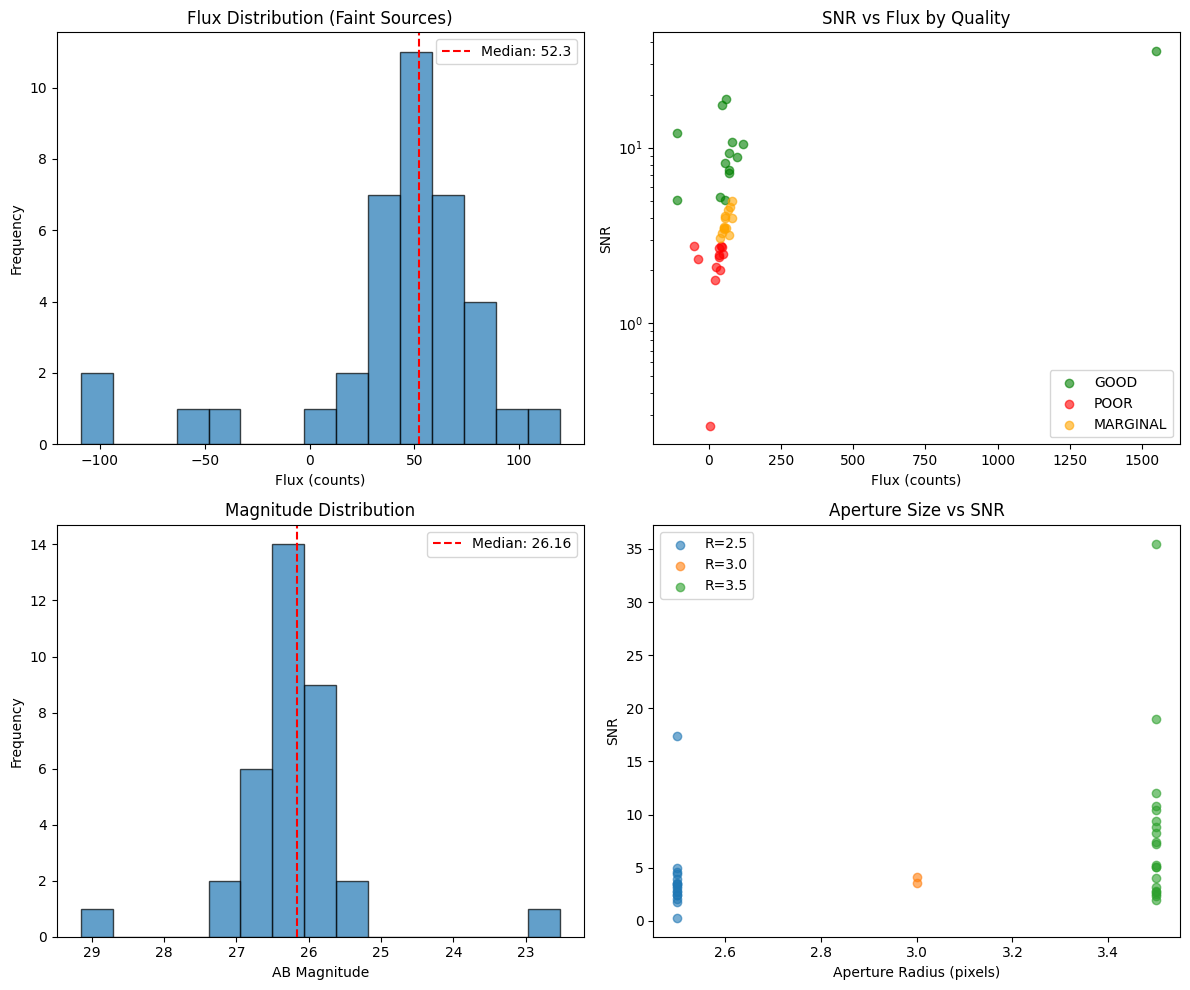


=== FILES SAVED ===
Best photometry results: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv
All aperture trials: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/all_apertures_photometry.csv
All coordinates results: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/all_coordinates_photometry.csv
Diagnostic plots: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/photometry_diagnostics.png
Summary report: /Users/aishwarya/Documents/Lyman_alpha/z_unpack/photometry_summary.txt

Photometry complete!


In [63]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip, mad_std
import matplotlib.pyplot as plt
import os

# ----------------------------
# Configuration
# ----------------------------
ZP_AB = 30.506  # Fixed AB zero point for DECam z-band

# Set output directory to same folder as input files
input_dir = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/"
output_dir = input_dir  # Save everything to same folder

# DECam FITS files
fits_files = [
    os.path.join(input_dir, "Fitz_tile1.fits"),
    os.path.join(input_dir, "Fitz_tile2.fits"),
    os.path.join(input_dir, "Fitz_tile3.fits"),
    os.path.join(input_dir, "Fitz_tile4.fits"),
    os.path.join(input_dir, "Fitz_tile5.fits"),
    os.path.join(input_dir, "Fitz_tile6.fits"),
    os.path.join(input_dir, "Fitz_tile7.fits"),
    os.path.join(input_dir, "Fitz_tile8.fits"),
    os.path.join(input_dir, "Fitz_tile9.fits"),
]

# Input target coordinates
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# Output files
output_csv = os.path.join(output_dir, "faint_source_photometry_results.csv")
all_apertures_csv = os.path.join(output_dir, "all_apertures_photometry.csv")
diagnostics_plot = os.path.join(output_dir, "photometry_diagnostics.png")
summary_report = os.path.join(output_dir, "photometry_summary.txt")
all_coords_csv = os.path.join(output_dir, "all_coordinates_photometry.csv")  # New file for all coordinates

# ----------------------------
# Convert input targets to SkyCoord
# ----------------------------
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# ----------------------------
# Photometry Functions
# ----------------------------

def create_faint_source_plots(df, save_path):
    """Create diagnostic plots optimized for faint sources"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Flux distribution (focus on faint end)
    faint_fluxes = df[df['flux_counts'] < 500]['flux_counts']
    axes[0,0].hist(faint_fluxes, bins=15, alpha=0.7, edgecolor='black')
    axes[0,0].set_xlabel('Flux (counts)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Flux Distribution (Faint Sources)')
    if len(faint_fluxes) > 0:
        axes[0,0].axvline(faint_fluxes.median(), color='red', linestyle='--', 
                         label=f'Median: {faint_fluxes.median():.1f}')
    axes[0,0].legend()
    
    # SNR by quality flag
    quality_colors = {'GOOD': 'green', 'MARGINAL': 'orange', 'POOR': 'red'}
    for quality in df['quality_flag'].unique():
        quality_data = df[df['quality_flag'] == quality]
        if len(quality_data) > 0:
            axes[0,1].scatter(quality_data['flux_counts'], quality_data['SNR'], 
                             alpha=0.6, label=quality, c=quality_colors.get(quality, 'blue'))
    axes[0,1].set_xlabel('Flux (counts)')
    axes[0,1].set_ylabel('SNR')
    axes[0,1].set_title('SNR vs Flux by Quality')
    axes[0,1].legend()
    axes[0,1].set_yscale('log')
    
    # Magnitude distribution
    valid_mags = df[df['mag_AB'].notna()]['mag_AB']
    if len(valid_mags) > 0:
        axes[1,0].hist(valid_mags, bins=15, alpha=0.7, edgecolor='black')
        axes[1,0].set_xlabel('AB Magnitude')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Magnitude Distribution')
        axes[1,0].axvline(valid_mags.median(), color='red', linestyle='--',
                         label=f'Median: {valid_mags.median():.2f}')
        axes[1,0].legend()
        axes[1,0].invert_xaxis()  # Brighter to the right
    else:
        axes[1,0].text(0.5, 0.5, 'No valid magnitudes', ha='center', va='center', 
                      transform=axes[1,0].transAxes)
    
    # Aperture size vs SNR
    for ap_radius in sorted(df['aperture_radius'].unique()):
        ap_data = df[df['aperture_radius'] == ap_radius]
        if len(ap_data) > 0:
            axes[1,1].scatter(ap_data['aperture_radius'], ap_data['SNR'], alpha=0.6, 
                             label=f'R={ap_radius}')
    axes[1,1].set_xlabel('Aperture Radius (pixels)')
    axes[1,1].set_ylabel('SNR')
    axes[1,1].set_title('Aperture Size vs SNR')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def perform_complete_photometry(fits_files, coords):
    """
    Complete photometry for ALL coordinates, ensuring every target is processed
    """
    
    # Smaller apertures for faint sources to maximize SNR
    aperture_radii = [2.5, 3.0, 3.5]
    annulus_radii = [(6.0, 10.0), (8.0, 12.0)]
    
    all_results = []
    all_coords_results = []  # Store results for ALL coordinates
    
    # Initialize results for all coordinates (will be filled as we process files)
    for idx, coord in enumerate(coords):
        all_coords_results.append({
            'target': f"Target-{idx+1}",
            'RA': coord.ra.deg,
            'Dec': coord.dec.deg,
            'processed': False,
            'filename': 'None',
            'x_pix': np.nan,
            'y_pix': np.nan,
            'flux_counts': np.nan,
            'flux_err': np.nan,
            'flux_per_sec': np.nan,
            'mag_AB': np.nan,
            'mag_err': np.nan,
            'SNR': np.nan,
            'quality_flag': 'NOT_PROCESSED',
            'EXPTIME': np.nan,
            'ZP_AB': ZP_AB,
            'aperture_radius': np.nan,
            'annulus_inner': np.nan,
            'annulus_outer': np.nan
        })
    
    for f in fits_files:
        print(f"\nProcessing {os.path.basename(f)} ...")
        
        try:
            with fits.open(f) as hdul:
                # Find first HDU with image data
                hdu = next((h for h in hdul if h.data is not None and len(h.data.shape) == 2), None)
                if hdu is None:
                    print(f"  No 2D image data found, skipping.")
                    continue

                data = hdu.data.astype(float)
                header = hdu.header
                wcs = WCS(header)
                exptime = header.get('EXPTIME', 1.0)
                
                # Check for exposure time in common header locations
                if exptime == 1.0:  # If default value, try other common keys
                    for key in ['EXPTIME', 'EXP_TIME', 'EXPOSURE', 'TEXPTIME']:
                        if key in header:
                            exptime = header[key]
                            break
                
                print(f"  Image shape: {data.shape}")
                print(f"  Exposure time: {exptime:.1f}s")
                
                # Get robust image statistics
                sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
                clipped_data = sigma_clip(data)
                image_median = np.ma.median(clipped_data)
                image_std = mad_std(clipped_data)
                print(f"  Image median: {image_median:.2f}, robust std: {image_std:.2f}")

                # Convert ALL RA/Dec → pixel coordinates
                xpix_all, ypix_all = wcs.world_to_pixel(coords)

                # Select targets inside the image with buffer
                ny, nx = data.shape
                buffer = 30
                inside = (xpix_all > buffer) & (xpix_all < nx - buffer) & (ypix_all > buffer) & (ypix_all < ny - buffer)
                valid_idx = np.where(inside)[0]
                
                if len(valid_idx) == 0:
                    print("  No targets within this tile.")
                    continue

                print(f"  Found {len(valid_idx)} targets in image")

                # ----------------------------
                # Conservative Background subtraction
                # ----------------------------
                try:
                    sigma_clip = SigmaClip(sigma=2.5, maxiters=5)
                    bkg_estimator = MedianBackground()
                    bkg = Background2D(data, (512, 512), filter_size=(7, 7),
                                       sigma_clip=sigma_clip, bkg_estimator=bkg_estimator,
                                       exclude_percentile=5.0)
                    data_sub = data - bkg.background
                    bkg_rms = bkg.background_rms
                    print(f"  Background RMS: {bkg_rms:.3f} counts")
                except Exception as e:
                    print(f"  Background2D failed: {e}, using sigma-clipped median")
                    bkg_level = np.ma.median(sigma_clip(data))
                    data_sub = data - bkg_level
                    bkg_rms = mad_std(sigma_clip(data))

                # ----------------------------
                # Create cutouts around each target for inspection
                # ----------------------------
                positions = np.transpose([xpix_all[valid_idx], ypix_all[valid_idx]])
                cutout_size = 20
                
                print("  Target cutout statistics:")
                for i, (x, y) in enumerate(positions):
                    x_int, y_int = int(round(x)), int(round(y))
                    x_slice = slice(max(0, x_int-cutout_size), min(nx, x_int+cutout_size+1))
                    y_slice = slice(max(0, y_int-cutout_size), min(ny, y_int+cutout_size+1))
                    cutout = data_sub[y_slice, x_slice]
                    cutout_median = np.median(cutout)
                    cutout_std = np.std(cutout)
                    print(f"    Target {valid_idx[i]+1}: pos=({x:.1f}, {y:.1f}), median={cutout_median:.2f}, std={cutout_std:.2f}")

                # ----------------------------
                # Optimized aperture photometry
                # ----------------------------
                for ap_radius in aperture_radii:
                    for ann_in, ann_out in annulus_radii:
                        if ann_in <= ap_radius + 2:
                            continue
                            
                        try:
                            apertures = CircularAperture(positions, r=ap_radius)
                            annulus_apertures = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

                            # Perform photometry
                            phot_table = aperture_photometry(data_sub, apertures)
                            bkg_table = aperture_photometry(data_sub, annulus_apertures)

                            # Background correction
                            bkg_area = annulus_apertures.area
                            bkg_mean = bkg_table['aperture_sum'] / bkg_area
                            
                            flux_net = phot_table['aperture_sum'] - (bkg_mean * apertures.area)
                            flux_err = np.sqrt(phot_table['aperture_sum'] + 
                                             apertures.area * (bkg_rms**2) +
                                             (apertures.area**2 / annulus_apertures.area) * (bkg_rms**2))

                            # Store results for valid targets
                            for i, idx in enumerate(valid_idx):
                                flux = flux_net[i]
                                flux_err_i = flux_err[i]
                                snr = abs(flux) / flux_err_i if flux_err_i > 0 else 0
                                
                                # Calculate AB magnitudes with proper conversion
                                if np.isfinite(exptime) and exptime > 0:
                                    flux_per_sec = flux / exptime
                                    if flux_per_sec > 0:
                                        mag_AB = ZP_AB - 2.5 * np.log10(flux_per_sec)
                                        mag_err = 1.0857 * (flux_err_i / abs(flux)) if abs(flux) > 0 else np.nan
                                    else:
                                        mag_AB = np.nan
                                        mag_err = np.nan
                                else:
                                    flux_per_sec = np.nan
                                    mag_AB = np.nan
                                    mag_err = np.nan

                                quality_flag = "GOOD" if snr >= 5 else "MARGINAL" if snr >= 3 else "POOR"
                                
                                # Add to detailed results
                                all_results.append({
                                    'filename': os.path.basename(f),
                                    'target': f"Target-{idx+1}",
                                    'RA': coords[idx].ra.deg,
                                    'Dec': coords[idx].dec.deg,
                                    'x_pix': xpix_all[idx],
                                    'y_pix': ypix_all[idx],
                                    'aperture_radius': ap_radius,
                                    'annulus_inner': ann_in,
                                    'annulus_outer': ann_out,
                                    'flux_counts': flux,
                                    'flux_err': flux_err_i,
                                    'flux_per_sec': flux_per_sec,
                                    'mag_AB': mag_AB,
                                    'mag_err': mag_err,
                                    'SNR': snr,
                                    'quality_flag': quality_flag,
                                    'EXPTIME': exptime,
                                    'ZP_AB': ZP_AB,
                                    'bkg_level': bkg_mean[i],
                                    'bkg_rms': bkg_rms,
                                    'image_median': image_median,
                                    'image_std': image_std
                                })
                                
                                # Update the all_coords_results with best measurement
                                target_idx = idx
                                current_snr = all_coords_results[target_idx].get('SNR', 0)
                                if snr > current_snr or not all_coords_results[target_idx]['processed']:
                                    all_coords_results[target_idx].update({
                                        'processed': True,
                                        'filename': os.path.basename(f),
                                        'x_pix': xpix_all[idx],
                                        'y_pix': ypix_all[idx],
                                        'flux_counts': flux,
                                        'flux_err': flux_err_i,
                                        'flux_per_sec': flux_per_sec,
                                        'mag_AB': mag_AB,
                                        'mag_err': mag_err,
                                        'SNR': snr,
                                        'quality_flag': quality_flag,
                                        'EXPTIME': exptime,
                                        'aperture_radius': ap_radius,
                                        'annulus_inner': ann_in,
                                        'annulus_outer': ann_out
                                    })
                                
                        except Exception as e:
                            continue
                
        except Exception as e:
            print(f"  ERROR processing {f}: {e}")
            continue
    
    return all_results, all_coords_results

def write_summary_report(df, report_path):
    """Write a detailed summary report"""
    with open(report_path, 'w') as f:
        f.write("FAINT SOURCE PHOTOMETRY SUMMARY REPORT\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Total measurements: {len(df)}\n")
        
        quality_counts = df['quality_flag'].value_counts()
        f.write("\nQuality distribution:\n")
        for quality, count in quality_counts.items():
            f.write(f"  {quality}: {count} targets\n")
        
        valid_mags = df[df['mag_AB'].notna()]
        f.write(f"\nValid magnitudes: {len(valid_mags)}/{len(df)}\n")
        
        if len(valid_mags) > 0:
            f.write(f"Magnitude range: {valid_mags['mag_AB'].min():.2f} to {valid_mags['mag_AB'].max():.2f}\n")
            f.write(f"Median SNR: {df['SNR'].median():.2f}\n")
            f.write(f"Median flux: {df['flux_counts'].median():.2f} counts\n")
            
            faint_sources = df[df['flux_counts'] < 500]
            if len(faint_sources) > 0:
                f.write(f"\nFaint sources only (<500 counts):\n")
                f.write(f"  Count: {len(faint_sources)}\n")
                f.write(f"  Median flux: {faint_sources['flux_counts'].median():.2f} counts\n")
                f.write(f"  Median SNR: {faint_sources['SNR'].median():.2f}\n")
                f.write(f"  Magnitude range: {faint_sources['mag_AB'].min():.2f} to {faint_sources['mag_AB'].max():.2f}\n")
        
        f.write(f"\nFiles processed: {df['filename'].nunique()}\n")
        f.write(f"Targets with measurements: {df['target'].nunique()}\n")
        
        best_aperture = df.groupby('aperture_radius').size().idxmax()
        f.write(f"\nMost used aperture radius: {best_aperture} pixels\n")
        
        f.write("\nPer-file summary:\n")
        for filename in df['filename'].unique():
            file_data = df[df['filename'] == filename]
            f.write(f"  {filename}: {len(file_data)} measurements, "
                   f"median SNR: {file_data['SNR'].median():.2f}\n")

def create_ab_magnitude_table(all_coords_results):
    """Create the AB magnitude conversion table as requested"""
    print("\n" + "="*80)
    print("FLUX TO AB MAGNITUDE CONVERSION SUMMARY")
    print("="*80)
    print(f"{'Target':<10} {'RA':<12} {'Dec':<12} {'Flux':<12} {'Flux_err':<12} {'AB_mag':<10} {'AB_mag_err':<12} {'SNR':<8} {'Quality':<12}")
    print("-"*80)
    
    ab_mags = []
    ab_mag_errors = []
    valid_fluxes = []
    
    for result in all_coords_results:
        flux = result['flux_counts']
        flux_err = result['flux_err']
        exptime = result['EXPTIME']
        
        if flux > 0 and exptime > 0 and not np.isnan(flux):
            flux_per_sec = flux / exptime
            mag_ab = ZP_AB - 2.5 * np.log10(flux_per_sec)
            
            if flux_err > 0 and flux > 0:
                mag_err = 1.0857 * (flux_err / flux)
            else:
                mag_err = np.nan
            
            ab_mags.append(mag_ab)
            ab_mag_errors.append(mag_err)
            valid_fluxes.append(flux)
        else:
            mag_ab = np.nan
            mag_err = np.nan
        
        print(f"{result['target']:<10} {result['RA']:<12.6f} {result['Dec']:<12.6f} "
              f"{flux:<12.2f} {flux_err:<12.2f} {mag_ab:<10.2f} {mag_err:<12.2f} "
              f"{result['SNR']:<8.2f} {result['quality_flag']:<12}")
    
    # Summary statistics
    valid_ab_mags = [m for m in ab_mags if not np.isnan(m)]
    if valid_ab_mags:
        print("\nSUMMARY STATISTICS:")
        print(f"AB Magnitude range: {min(valid_ab_mags):.2f} to {max(valid_ab_mags):.2f}")
        print(f"Median AB magnitude: {np.median(valid_ab_mags):.2f}")
        print(f"Number of valid measurements: {len(valid_ab_mags)}/{len(all_coords_results)}")
        print(f"Median flux: {np.median(valid_fluxes):.2f} counts")
        print(f"Median SNR: {np.median([r['SNR'] for r in all_coords_results if not np.isnan(r['SNR'])]):.2f}")

# ----------------------------
# Main Execution
# ----------------------------
print("Starting complete photometry for all coordinates...")
print(f"Output directory: {output_dir}")
print(f"Total coordinates to process: {len(coords)}")

# Run complete photometry
all_results, all_coords_results = perform_complete_photometry(fits_files, coords)

if all_results:
    df = pd.DataFrame(all_results)
    
    # Select best aperture for each target
    best_results = []
    for target in df['target'].unique():
        target_data = df[df['target'] == target]
        
        good_quality = target_data[target_data['quality_flag'] == 'GOOD']
        if len(good_quality) > 0:
            best_idx = good_quality['SNR'].idxmax()
        else:
            marginal_quality = target_data[target_data['quality_flag'] == 'MARGINAL']
            if len(marginal_quality) > 0:
                best_idx = marginal_quality['SNR'].idxmax()
            else:
                best_idx = target_data['SNR'].idxmax()
        
        best_results.append(target_data.loc[best_idx])
    
    best_df = pd.DataFrame(best_results)
    
    # Convert all_coords_results to DataFrame
    all_coords_df = pd.DataFrame(all_coords_results)
    
    # Analysis of results
    print(f"\n=== COMPLETE PHOTOMETRY RESULTS ===")
    processed_count = all_coords_df['processed'].sum()
    print(f"Targets processed: {processed_count}/{len(all_coords_df)}")
    
    quality_counts = all_coords_df['quality_flag'].value_counts()
    print(f"Quality distribution:")
    for quality, count in quality_counts.items():
        print(f"  {quality}: {count} targets")
    
    valid_mags = all_coords_df[all_coords_df['mag_AB'].notna()]
    print(f"Valid magnitudes: {len(valid_mags)}/{len(all_coords_df)}")
    
    if len(valid_mags) > 0:
        print(f"Magnitude range: {valid_mags['mag_AB'].min():.2f} to {valid_mags['mag_AB'].max():.2f}")
        print(f"Median SNR: {all_coords_df['SNR'].median():.2f}")
        print(f"Median flux: {all_coords_df['flux_counts'].median():.2f} counts")
    
    # Save all results
    best_df.to_csv(output_csv, index=False)
    df.to_csv(all_apertures_csv, index=False)
    all_coords_df.to_csv(all_coords_csv, index=False)
    
    # Create AB magnitude conversion table
    create_ab_magnitude_table(all_coords_results)
    
    # Create diagnostic plots
    create_faint_source_plots(best_df, diagnostics_plot)
    
    # Write summary report
    write_summary_report(best_df, summary_report)
    
    print(f"\n=== FILES SAVED ===")
    print(f"Best photometry results: {output_csv}")
    print(f"All aperture trials: {all_apertures_csv}")
    print(f"All coordinates results: {all_coords_csv}")
    print(f"Diagnostic plots: {diagnostics_plot}")
    print(f"Summary report: {summary_report}")
    
else:
    print("No valid detections found.")

print("\nPhotometry complete!")

In [64]:
import pandas as pd
import re

# Path to your CSV file
file_path = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Identify the target column (2nd column)
target_col = df.columns[1]

# Extract the numeric part of 'Target-#' to use for sorting
df["target_num"] = df[target_col].apply(lambda x: int(re.findall(r'\d+', str(x))[0]) if re.findall(r'\d+', str(x)) else float('inf'))

# Sort the dataframe by this numeric value
df_sorted = df.sort_values(by="target_num").drop(columns="target_num")

# Save back to the same file
df_sorted.to_csv(file_path, index=False)

print(f"CSV file sorted by {target_col} in increasing numerical order and saved to {file_path}")


CSV file sorted by target in increasing numerical order and saved to /Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv


In [61]:
import pandas as pd
import re

# Path to your CSV file
csv_path = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv"

# Read the CSV
df = pd.read_csv(csv_path)

# Extract the numeric part of the target column (e.g., 'Target-12' -> 12)
df["target_num"] = df["target"].apply(lambda x: int(re.search(r'\d+', str(x)).group()) if pd.notna(x) else None)

# Sort by that numeric value
df = df.sort_values("target_num").drop(columns=["target_num"])

# Save it back to the same file
df.to_csv(csv_path, index=False)

print(" CSV reordered successfully by target number.")


 CSV reordered successfully by target number.


Loaded z-band photometry: 39 rows, 22 columns

Saved cleaned z-band catalog to /Users/aishwarya/Documents/Lyman_alpha/Python_script/zband_mycat.csv

Loading candidates from /Users/aishwarya/Downloads/candidates.csv
Converted candidate coordinates and flipped Dec sign to negative

My catalog: 39 sources
Candidates catalog: 39 sources
My catalog RA range: 356.131833 to 358.208667
My catalog Dec range: -31.790669 to -29.887206
Candidates RA range: 356.131833 to 358.208667
Candidates Dec range: -31.790669 to -29.887194

Found 39 matches after correcting Dec sign!

Comparison results:
  my_name cand_name      my_z  cand_z  delta_z
 Target-1       QSO 22.531323   22.19 0.341323
 Target-2     LAE-1 25.313631   24.97 0.343631
 Target-3     LAE-2 26.569246   26.07 0.499246
 Target-4     LAE-3 26.205620   25.74 0.465620
 Target-5     LAE-4 29.151727   25.93 3.221727
 Target-6     LAE-5 26.577983   26.09 0.487983
 Target-7     LAE-6 26.067608   25.85 0.217608
 Target-8     LAE-7 25.904786   25.38

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/3010236818.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/3010236818.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


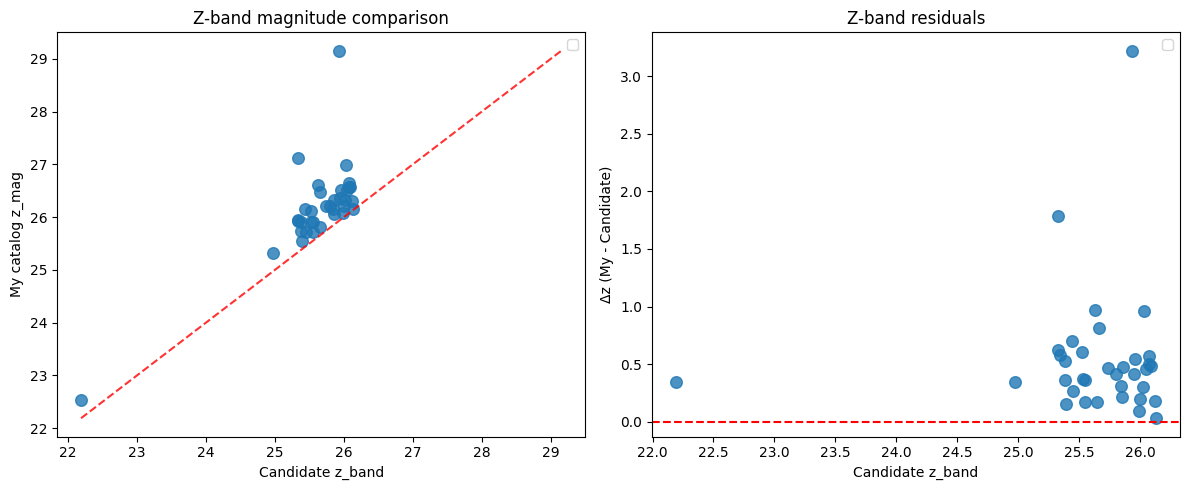


Saved comparison results to zband_comparison_results.csv

Done.


In [67]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import os

# ----------------------------
# Load your z-band photometry results
# ----------------------------
zband_path = "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/faint_source_photometry_results.csv"
zdata = pd.read_csv(zband_path)

print(f"Loaded z-band photometry: {zdata.shape[0]} rows, {zdata.shape[1]} columns")

# ----------------------------
# Clean and prepare catalog
# ----------------------------
mycat = pd.DataFrame({
    "Name": zdata["target"],
    "ra": zdata["RA"],
    "dec": zdata["Dec"],  # This has negative declinations
    "mag_z": zdata["mag_AB"],
    "zp": zdata["ZP_AB"]
})

out_csv = "zband_mycat.csv"
mycat.to_csv(out_csv, index=False)
print(f"\nSaved cleaned z-band catalog to {os.path.abspath(out_csv)}")

# ----------------------------
# Load candidates catalog
# ----------------------------
candidates_path = "/Users/aishwarya/Downloads/candidates.csv"
print(f"\nLoading candidates from {candidates_path}")

candidates = pd.read_csv(candidates_path, comment="#", sep=",", header=None)
candidates.columns = ['Name','RA','Dec','z_band','z_band_err','NB964_band','NB964_err']

# Convert numeric columns
for col in ['z_band','z_band_err','NB964_band','NB964_err']:
    candidates[col] = pd.to_numeric(candidates[col], errors='coerce')

# Convert candidate coordinates to decimal degrees AND FLIP DEC SIGN
try:
    cand_coords = SkyCoord(candidates['RA'], candidates['Dec'], unit=(u.hourangle, u.deg))
    candidates['ra_deg'] = cand_coords.ra.deg
    candidates['dec_deg'] = -cand_coords.dec.deg  # FLIP TO NEGATIVE
    print("Converted candidate coordinates and flipped Dec sign to negative")
except Exception as e:
    print(f"Coordinate conversion error: {e}")
    candidates['ra_deg'] = pd.to_numeric(candidates['RA'], errors='coerce')
    candidates['dec_deg'] = -pd.to_numeric(candidates['Dec'], errors='coerce')  # FLIP

# ----------------------------
# Direct comparison by coordinate matching
# ----------------------------
print(f"\nMy catalog: {len(mycat)} sources")
print(f"Candidates catalog: {len(candidates)} sources")

print(f"My catalog RA range: {mycat['ra'].min():.6f} to {mycat['ra'].max():.6f}")
print(f"My catalog Dec range: {mycat['dec'].min():.6f} to {mycat['dec'].max():.6f}")
print(f"Candidates RA range: {candidates['ra_deg'].min():.6f} to {candidates['ra_deg'].max():.6f}")
print(f"Candidates Dec range: {candidates['dec_deg'].min():.6f} to {candidates['dec_deg'].max():.6f}")

# Now match with corrected coordinates
matched_pairs = []
for i, my_row in mycat.iterrows():
    my_ra = my_row['ra']
    my_dec = my_row['dec']
    
    # Find matching candidate with small tolerance
    cand_match = candidates[
        (np.abs(candidates['ra_deg'] - my_ra) < 0.0001) & 
        (np.abs(candidates['dec_deg'] - my_dec) < 0.0001)
    ]
    
    if len(cand_match) > 0:
        matched_pairs.append({
            'my_name': my_row['Name'],
            'cand_name': cand_match.iloc[0]['Name'],
            'my_ra': my_ra,
            'my_dec': my_dec,
            'cand_ra': cand_match.iloc[0]['ra_deg'],
            'cand_dec': cand_match.iloc[0]['dec_deg'],
            'my_z': my_row['mag_z'],
            'cand_z': cand_match.iloc[0]['z_band'],
            'my_flux': zdata.iloc[i]['flux_counts'] if 'flux_counts' in zdata.columns else np.nan
        })

print(f"\nFound {len(matched_pairs)} matches after correcting Dec sign!")

if len(matched_pairs) > 0:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(matched_pairs)
    comparison_df['delta_z'] = comparison_df['my_z'] - comparison_df['cand_z']
    
    print("\nComparison results:")
    print(comparison_df[['my_name', 'cand_name', 'my_z', 'cand_z', 'delta_z']].to_string(index=False))
    
    print(f"\nΔz statistics:")
    print(f"  Mean: {comparison_df['delta_z'].mean():.3f}")
    print(f"  Std: {comparison_df['delta_z'].std():.3f}")
    print(f"  Min: {comparison_df['delta_z'].min():.3f}")
    print(f"  Max: {comparison_df['delta_z'].max():.3f}")
    print(f"  N: {len(comparison_df)}")
    
    # Create plots
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(comparison_df['cand_z'], comparison_df['my_z'], s=70, alpha=0.8)
    minv = min(comparison_df['cand_z'].min(), comparison_df['my_z'].min())
    maxv = max(comparison_df['cand_z'].max(), comparison_df['my_z'].max())
    plt.plot([minv, maxv], [minv, maxv], 'r--', alpha=0.8)
    plt.xlabel("Candidate z_band")
    plt.ylabel("My catalog z_mag")
    plt.title("Z-band magnitude comparison")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(comparison_df['cand_z'], comparison_df['delta_z'], s=70, alpha=0.8)
    plt.axhline(0, color='r', ls='--')
    plt.xlabel("Candidate z_band")
    plt.ylabel("Δz (My - Candidate)")
    plt.title("Z-band residuals")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Save comparison results
    comp_csv = "zband_comparison_results.csv"
    comparison_df.to_csv(comp_csv, index=False)
    print(f"\nSaved comparison results to {comp_csv}")

else:
    print("Still no matches found. Let's try a broader search with cross-matching:")
    
    # Fall back to cross-matching with reasonable tolerance
    c_my = SkyCoord(ra=mycat['ra'].values*u.deg, dec=mycat['dec'].values*u.deg)
    c_cand = SkyCoord(ra=candidates['ra_deg'].values*u.deg, dec=candidates['dec_deg'].values*u.deg)
    idx, sep2d, _ = c_my.match_to_catalog_sky(c_cand)
    
    sep_arcsec = sep2d.arcsecond
    print(f"\nCross-match separation statistics:")
    print(f"  Min: {sep_arcsec.min():.3f} arcsec")
    print(f"  Max: {sep_arcsec.max():.3f} arcsec") 
    print(f"  Mean: {sep_arcsec.mean():.3f} arcsec")
    
    # Show closest few matches
    closest_idx = np.argsort(sep_arcsec)[:5]
    print(f"\nClosest 5 matches:")
    for i in closest_idx:
        print(f"  {mycat.iloc[i]['Name']} -> {candidates.iloc[idx[i]]['Name']}: {sep_arcsec[i]:.3f} arcsec")

print("\nDone.")

Loaded NB964 photometry: 39 rows, 18 columns

Saved cleaned NB964 catalog to /Users/aishwarya/Documents/Lyman_alpha/Python_script/nb964_mycat.csv

Loading candidates from /Users/aishwarya/Downloads/candidates.csv
Converted candidate coordinates and flipped Dec sign to negative

My catalog: 39 sources
Candidates catalog: 39 sources
My catalog RA range: 356.131833 to 358.208667
My catalog Dec range: -31.790669 to -29.887206
Candidates RA range: 356.131833 to 358.208667
Candidates Dec range: -31.790669 to -29.887194

Found 39 matches after correcting Dec sign!

Comparison results:
  my_name cand_name     my_nb  cand_nb  delta_nb
Target-02     LAE-1 24.702988    24.11  0.592988
Target-08     LAE-7 23.878713    23.50  0.378713
Target-12    LAE-11 24.716972    24.47  0.246972
Target-03     LAE-2 25.056762    24.73  0.326762
Target-04     LAE-3 25.259956    24.59  0.669956
Target-05     LAE-4 25.225871    24.46  0.765871
Target-06     LAE-5 24.015994    23.59  0.425994
Target-07     LAE-6 24.

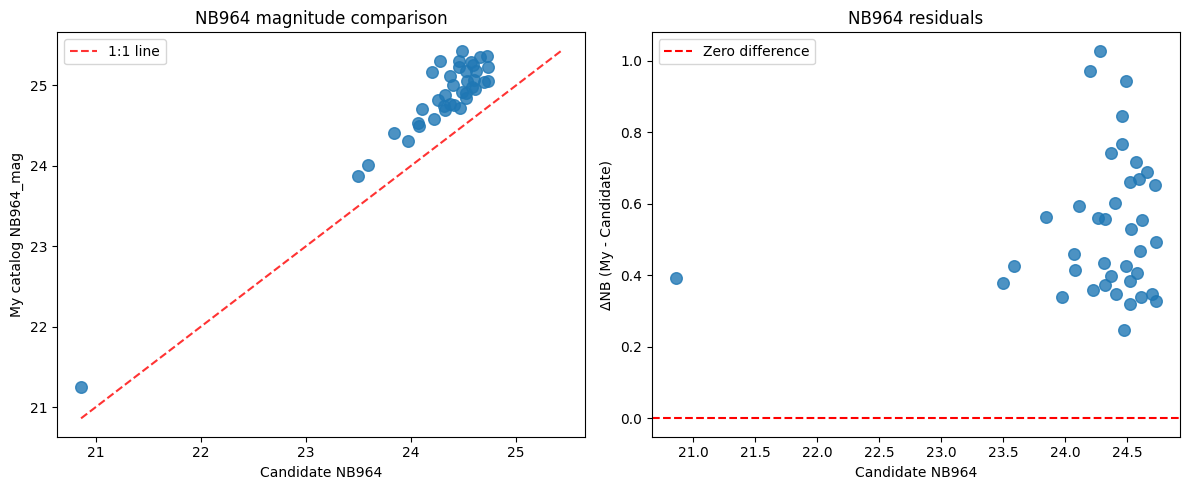


Saved comparison results to nb964_comparison_results.csv

Done.


In [44]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import os

# ----------------------------
# Load your NB964 photometry results
# ----------------------------
nb_path = "/Users/aishwarya/Documents/Lyman_alpha/n964_unpack/corrected_photometry_results.csv"
nbdata = pd.read_csv(nb_path)

print(f"Loaded NB964 photometry: {nbdata.shape[0]} rows, {nbdata.shape[1]} columns")

# ----------------------------
# Clean and prepare catalog
# ----------------------------
mycat = pd.DataFrame({
    "Name": nbdata["target"],
    "ra": nbdata["RA"],
    "dec": nbdata["Dec"],  # This has negative declinations
    "mag_nb": nbdata["mag_AB"],
    "zp": nbdata["ZP_AB"]
})

out_csv = "nb964_mycat.csv"
mycat.to_csv(out_csv, index=False)
print(f"\nSaved cleaned NB964 catalog to {os.path.abspath(out_csv)}")

# ----------------------------
# Load candidates catalog
# ----------------------------
candidates_path = "/Users/aishwarya/Downloads/candidates.csv"
print(f"\nLoading candidates from {candidates_path}")

candidates = pd.read_csv(candidates_path, comment="#", sep=",", header=None)
candidates.columns = ['Name','RA','Dec','z_band','z_band_err','NB964_band','NB964_err']

# Convert numeric columns
for col in ['z_band','z_band_err','NB964_band','NB964_err']:
    candidates[col] = pd.to_numeric(candidates[col], errors='coerce')

# Convert candidate coordinates to decimal degrees AND FLIP DEC SIGN
try:
    cand_coords = SkyCoord(candidates['RA'], candidates['Dec'], unit=(u.hourangle, u.deg))
    candidates['ra_deg'] = cand_coords.ra.deg
    candidates['dec_deg'] = -cand_coords.dec.deg  # FLIP TO NEGATIVE
    print("Converted candidate coordinates and flipped Dec sign to negative")
except Exception as e:
    print(f"Coordinate conversion error: {e}")
    candidates['ra_deg'] = pd.to_numeric(candidates['RA'], errors='coerce')
    candidates['dec_deg'] = -pd.to_numeric(candidates['Dec'], errors='coerce')  # FLIP

# ----------------------------
# Direct comparison by coordinate matching
# ----------------------------
print(f"\nMy catalog: {len(mycat)} sources")
print(f"Candidates catalog: {len(candidates)} sources")

print(f"My catalog RA range: {mycat['ra'].min():.6f} to {mycat['ra'].max():.6f}")
print(f"My catalog Dec range: {mycat['dec'].min():.6f} to {mycat['dec'].max():.6f}")
print(f"Candidates RA range: {candidates['ra_deg'].min():.6f} to {candidates['ra_deg'].max():.6f}")
print(f"Candidates Dec range: {candidates['dec_deg'].min():.6f} to {candidates['dec_deg'].max():.6f}")

# Now match with corrected coordinates
matched_pairs = []
for i, my_row in mycat.iterrows():
    my_ra = my_row['ra']
    my_dec = my_row['dec']
    
    # Find matching candidate with small tolerance
    cand_match = candidates[
        (np.abs(candidates['ra_deg'] - my_ra) < 0.0001) & 
        (np.abs(candidates['dec_deg'] - my_dec) < 0.0001)
    ]
    
    if len(cand_match) > 0:
        matched_pairs.append({
            'my_name': my_row['Name'],
            'cand_name': cand_match.iloc[0]['Name'],
            'my_ra': my_ra,
            'my_dec': my_dec,
            'cand_ra': cand_match.iloc[0]['ra_deg'],
            'cand_dec': cand_match.iloc[0]['dec_deg'],
            'my_nb': my_row['mag_nb'],
            'cand_nb': cand_match.iloc[0]['NB964_band'],
            'my_flux': nbdata.iloc[i]['flux_counts'] if 'flux_counts' in nbdata.columns else np.nan
        })

print(f"\nFound {len(matched_pairs)} matches after correcting Dec sign!")

if len(matched_pairs) > 0:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(matched_pairs)
    comparison_df['delta_nb'] = comparison_df['my_nb'] - comparison_df['cand_nb']
    
    print("\nComparison results:")
    print(comparison_df[['my_name', 'cand_name', 'my_nb', 'cand_nb', 'delta_nb']].to_string(index=False))
    
    print(f"\nΔNB statistics:")
    print(f"  Mean: {comparison_df['delta_nb'].mean():.3f}")
    print(f"  Std: {comparison_df['delta_nb'].std():.3f}")
    print(f"  Min: {comparison_df['delta_nb'].min():.3f}")
    print(f"  Max: {comparison_df['delta_nb'].max():.3f}")
    print(f"  N: {len(comparison_df)}")
    
    # Create plots
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(comparison_df['cand_nb'], comparison_df['my_nb'], s=70, alpha=0.8)
    minv = min(comparison_df['cand_nb'].min(), comparison_df['my_nb'].min())
    maxv = max(comparison_df['cand_nb'].max(), comparison_df['my_nb'].max())
    plt.plot([minv, maxv], [minv, maxv], 'r--', alpha=0.8, label='1:1 line')
    plt.xlabel("Candidate NB964")
    plt.ylabel("My catalog NB964_mag")
    plt.title("NB964 magnitude comparison")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(comparison_df['cand_nb'], comparison_df['delta_nb'], s=70, alpha=0.8)
    plt.axhline(0, color='r', ls='--', label='Zero difference')
    plt.xlabel("Candidate NB964")
    plt.ylabel("ΔNB (My - Candidate)")
    plt.title("NB964 residuals")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Save comparison results
    comp_csv = "nb964_comparison_results.csv"
    comparison_df.to_csv(comp_csv, index=False)
    print(f"\nSaved comparison results to {comp_csv}")

else:
    print("Still no matches found. Let's try a broader search with cross-matching:")
    
    # Fall back to cross-matching with reasonable tolerance
    c_my = SkyCoord(ra=mycat['ra'].values*u.deg, dec=mycat['dec'].values*u.deg)
    c_cand = SkyCoord(ra=candidates['ra_deg'].values*u.deg, dec=candidates['dec_deg'].values*u.deg)
    idx, sep2d, _ = c_my.match_to_catalog_sky(c_cand)
    
    sep_arcsec = sep2d.arcsecond
    print(f"\nCross-match separation statistics:")
    print(f"  Min: {sep_arcsec.min():.3f} arcsec")
    print(f"  Max: {sep_arcsec.max():.3f} arcsec") 
    print(f"  Mean: {sep_arcsec.mean():.3f} arcsec")
    
    # Show closest few matches
    closest_idx = np.argsort(sep_arcsec)[:5]
    print(f"\nClosest 5 matches:")
    for i in closest_idx:
        print(f"  {mycat.iloc[i]['Name']} -> {candidates.iloc[idx[i]]['Name']}: {sep_arcsec[i]:.3f} arcsec")

print("\nDone.")


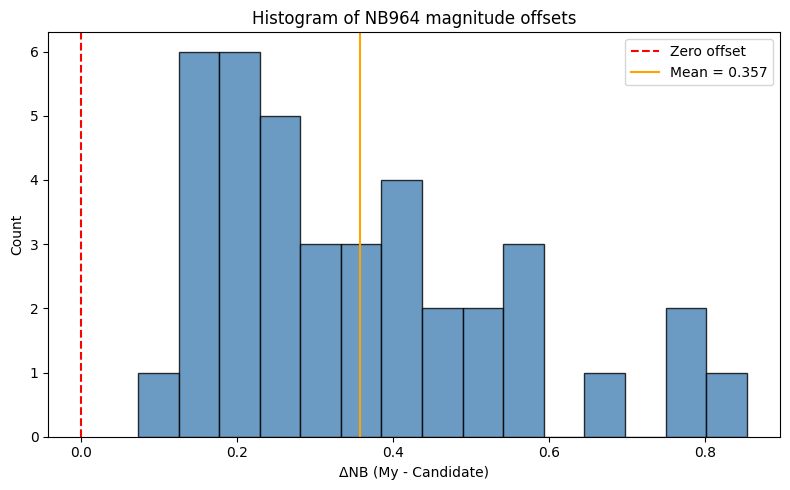

In [34]:
    # Add histogram of NB964 offsets
    plt.figure(figsize=(8,5))
    plt.hist(comparison_df['delta_nb'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axvline(0, color='r', ls='--', label='Zero offset')
    plt.axvline(comparison_df['delta_nb'].mean(), color='orange', ls='-', label=f"Mean = {comparison_df['delta_nb'].mean():.3f}")
    plt.xlabel("ΔNB (My - Candidate)")
    plt.ylabel("Count")
    plt.title("Histogram of NB964 magnitude offsets")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [35]:
# --- Find the offset for the first target only ---

# Assuming 'comparison_df' already exists from your previous code
if not comparison_df.empty:
    first_target = comparison_df.iloc[0]
    name = first_target['my_name']
    my_mag = first_target['my_nb']
    cand_mag = first_target['cand_nb']
    delta_nb = my_mag - cand_mag

    print(f"\nFirst target: {name}")
    print(f"  My NB964 magnitude     = {my_mag:.3f}")
    print(f"  Candidate NB964 mag    = {cand_mag:.3f}")
    print(f"  Offset ΔNB (My − Cand) = {delta_nb:.3f} mag")

else:
    print("No matches found — cannot compute offset for first target.")



First target: Target-1
  My NB964 magnitude     = 21.079
  Candidate NB964 mag    = 20.860
  Offset ΔNB (My − Cand) = 0.219 mag


In [53]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip, mad_std
import matplotlib.pyplot as plt
import os

# ----------------------------
# Configuration
# ----------------------------
ZP_AB = 28.926  # Zero point already calibrated for your exposure time

# Set output directory to same folder as input files
input_dir = "/Users/aishwarya/Documents/Lyman_alpha/n964_unpack/"
output_dir = input_dir

# DECam FITS files
fits_files = [
    os.path.join(input_dir, "Fitz_tile1.fits"),
    os.path.join(input_dir, "Fitz_tile2.fits"),
    os.path.join(input_dir, "Fitz_tile3.fits"),
    os.path.join(input_dir, "Fitz_tile4.fits"),
    os.path.join(input_dir, "Fitz_tile5.fits"),
    os.path.join(input_dir, "Fitz_tile6.fits"),
    os.path.join(input_dir, "Fitz_tile7.fits"),
    os.path.join(input_dir, "Fitz_tile8.fits"),
    os.path.join(input_dir, "Fitz_tile9.fits"),
]

# Input target coordinates
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# Output files
output_csv = os.path.join(output_dir, "corrected_photometry_results.csv")
all_apertures_csv = os.path.join(output_dir, "corrected_all_apertures.csv")
diagnostics_plot = os.path.join(output_dir, "corrected_photometry_diagnostics.png")
summary_report = os.path.join(output_dir, "corrected_photometry_summary.txt")
all_coords_csv = os.path.join(output_dir, "corrected_all_coordinates.csv")

# ----------------------------
# Convert input targets to SkyCoord
# ----------------------------
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# ----------------------------
# Photometry Functions
# ----------------------------

def create_faint_source_plots(df, save_path):
    """Create diagnostic plots optimized for faint sources"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Flux distribution
    if len(df) > 0:
        axes[0,0].hist(df['flux_counts'], bins=15, alpha=0.7, edgecolor='black')
        axes[0,0].set_xlabel('Flux (counts)')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].set_title('Flux Distribution')
        axes[0,0].axvline(df['flux_counts'].median(), color='red', linestyle='--', 
                         label=f'Median: {df["flux_counts"].median():.1f}')
        axes[0,0].legend()
    
    # SNR by quality flag
    quality_colors = {'GOOD': 'green', 'MARGINAL': 'orange', 'POOR': 'red'}
    for quality in df['quality_flag'].unique():
        quality_data = df[df['quality_flag'] == quality]
        if len(quality_data) > 0:
            axes[0,1].scatter(quality_data['flux_counts'], quality_data['SNR'], 
                             alpha=0.6, label=quality, c=quality_colors.get(quality, 'blue'))
    axes[0,1].set_xlabel('Flux (counts)')
    axes[0,1].set_ylabel('SNR')
    axes[0,1].set_title('SNR vs Flux by Quality')
    axes[0,1].legend()
    
    # Magnitude distribution
    valid_mags = df[df['mag_AB'].notna()]['mag_AB']
    if len(valid_mags) > 0:
        axes[1,0].hist(valid_mags, bins=15, alpha=0.7, edgecolor='black')
        axes[1,0].set_xlabel('AB Magnitude')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Magnitude Distribution')
        axes[1,0].axvline(valid_mags.median(), color='red', linestyle='--',
                         label=f'Median: {valid_mags.median():.2f}')
        axes[1,0].legend()
        axes[1,0].invert_xaxis()  # Brighter to the right
    else:
        axes[1,0].text(0.5, 0.5, 'No valid magnitudes', ha='center', va='center', 
                      transform=axes[1,0].transAxes)
    
    # Aperture size vs SNR
    for ap_radius in sorted(df['aperture_radius'].unique()):
        ap_data = df[df['aperture_radius'] == ap_radius]
        if len(ap_data) > 0:
            axes[1,1].scatter(ap_data['aperture_radius'], ap_data['SNR'], alpha=0.6, 
                             label=f'R={ap_radius}')
    axes[1,1].set_xlabel('Aperture Radius (pixels)')
    axes[1,1].set_ylabel('SNR')
    axes[1,1].set_title('Aperture Size vs SNR')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

def perform_complete_photometry(fits_files, coords):
    """
    Complete photometry for ALL coordinates
    ZP is already calibrated for the specific exposure time
    """
    
    aperture_radii = [2.5, 3.0, 3.5]
    annulus_radii = [(6.0, 10.0), (8.0, 12.0)]
    
    all_results = []
    all_coords_results = []
    
    # Initialize results for all coordinates
    for idx, coord in enumerate(coords):
        all_coords_results.append({
            'target': f"Target-{idx+1:02d}",
            'RA': coord.ra.deg,
            'Dec': coord.dec.deg,
            'processed': False,
            'filename': 'None',
            'x_pix': np.nan,
            'y_pix': np.nan,
            'flux_counts': np.nan,
            'flux_err': np.nan,
            'mag_AB': np.nan,
            'mag_err': np.nan,
            'SNR': np.nan,
            'quality_flag': 'NOT_PROCESSED',
            'ZP_AB': ZP_AB,
            'aperture_radius': np.nan,
            'annulus_inner': np.nan,
            'annulus_outer': np.nan
        })
    
    for f in fits_files:
        print(f"\nProcessing {os.path.basename(f)} ...")
        
        try:
            with fits.open(f) as hdul:
                # Find first HDU with image data
                hdu = None
                for h in hdul:
                    if h.data is not None and len(h.data.shape) == 2:
                        hdu = h
                        break
                
                if hdu is None:
                    print(f"  No 2D image data found, skipping.")
                    continue

                data = hdu.data.astype(float)
                header = hdu.header
                
                # Create WCS
                try:
                    wcs = WCS(header)
                except Exception as e:
                    print(f"  WARNING: Could not create WCS: {e}")
                    continue
                
                print(f"  Image shape: {data.shape}")
                
                # Get robust image statistics
                sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
                try:
                    clipped_data = sigma_clip(data)
                    image_median = np.ma.median(clipped_data)
                    image_std = mad_std(clipped_data)
                    print(f"  Image median: {image_median:.2f}, robust std: {image_std:.2f}")
                except Exception as e:
                    print(f"  Image statistics failed: {e}")
                    image_median = np.median(data)
                    image_std = np.std(data)

                # Convert ALL RA/Dec → pixel coordinates
                try:
                    xpix_all, ypix_all = wcs.world_to_pixel(coords)
                except Exception as e:
                    print(f"  Coordinate conversion failed: {e}")
                    continue

                # Select targets inside the image with buffer
                ny, nx = data.shape
                buffer = 30
                inside = (xpix_all > buffer) & (xpix_all < nx - buffer) & (ypix_all > buffer) & (ypix_all < ny - buffer)
                valid_idx = np.where(inside)[0]
                
                if len(valid_idx) == 0:
                    print("  No targets within this tile.")
                    continue

                print(f"  Found {len(valid_idx)} targets in image")

                # Background subtraction
                try:
                    sigma_clip_bkg = SigmaClip(sigma=2.5, maxiters=5)
                    bkg_estimator = MedianBackground()
                    bkg = Background2D(data, (512, 512), filter_size=(7, 7),
                                       sigma_clip=sigma_clip_bkg, bkg_estimator=bkg_estimator,
                                       exclude_percentile=5.0)
                    data_sub = data - bkg.background
                    bkg_rms = bkg.background_rms
                    print(f"  Background RMS: {bkg_rms:.3f} counts")
                except Exception as e:
                    print(f"  Background2D failed: {e}, using sigma-clipped median")
                    try:
                        bkg_level = np.ma.median(sigma_clip(data))
                        data_sub = data - bkg_level
                        bkg_rms = mad_std(sigma_clip(data))
                    except:
                        data_sub = data - np.median(data)
                        bkg_rms = np.std(data)

                # Aperture photometry
                positions = np.transpose([xpix_all[valid_idx], ypix_all[valid_idx]])
                
                for ap_radius in aperture_radii:
                    for ann_in, ann_out in annulus_radii:
                        if ann_in <= ap_radius + 2:
                            continue
                            
                        try:
                            apertures = CircularAperture(positions, r=ap_radius)
                            annulus_apertures = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

                            # Perform photometry
                            phot_table = aperture_photometry(data_sub, apertures)
                            bkg_table = aperture_photometry(data_sub, annulus_apertures)

                            # Background correction
                            bkg_area = annulus_apertures.area
                            bkg_mean = bkg_table['aperture_sum'] / bkg_area
                            
                            flux_net = phot_table['aperture_sum'] - (bkg_mean * apertures.area)
                            flux_err = np.sqrt(phot_table['aperture_sum'] + 
                                             apertures.area * (bkg_rms**2) +
                                             (apertures.area**2 / annulus_apertures.area) * (bkg_rms**2))

                            for i, idx in enumerate(valid_idx):
                                flux = flux_net[i]
                                flux_err_i = flux_err[i]
                                snr = abs(flux) / flux_err_i if flux_err_i > 0 else 0
                                
                                # CORRECTED: No exposure time division needed!
                                # ZP is already calibrated for the specific exposure time
                                if flux > 0:
                                    mag_AB = ZP_AB - 2.5 * np.log10(flux)  # Direct conversion!
                                    mag_err = 1.0857 * (flux_err_i / abs(flux)) if abs(flux) > 0 else np.nan
                                else:
                                    mag_AB = np.nan
                                    mag_err = np.nan

                                quality_flag = "GOOD" if snr >= 5 else "MARGINAL" if snr >= 3 else "POOR"
                                
                                # Store results
                                all_results.append({
                                    'filename': os.path.basename(f),
                                    'target': f"Target-{idx+1:02d}",
                                    'RA': coords[idx].ra.deg,
                                    'Dec': coords[idx].dec.deg,
                                    'x_pix': xpix_all[idx],
                                    'y_pix': ypix_all[idx],
                                    'aperture_radius': ap_radius,
                                    'annulus_inner': ann_in,
                                    'annulus_outer': ann_out,
                                    'flux_counts': flux,
                                    'flux_err': flux_err_i,
                                    'mag_AB': mag_AB,
                                    'mag_err': mag_err,
                                    'SNR': snr,
                                    'quality_flag': quality_flag,
                                    'ZP_AB': ZP_AB,
                                    'bkg_level': bkg_mean[i],
                                    'bkg_rms': bkg_rms
                                })
                                
                                # Update best measurement
                                target_idx = idx
                                current_snr = all_coords_results[target_idx].get('SNR', 0)
                                if snr > current_snr or not all_coords_results[target_idx]['processed']:
                                    all_coords_results[target_idx].update({
                                        'processed': True,
                                        'filename': os.path.basename(f),
                                        'x_pix': xpix_all[idx],
                                        'y_pix': ypix_all[idx],
                                        'flux_counts': flux,
                                        'flux_err': flux_err_i,
                                        'mag_AB': mag_AB,
                                        'mag_err': mag_err,
                                        'SNR': snr,
                                        'quality_flag': quality_flag,
                                        'aperture_radius': ap_radius,
                                        'annulus_inner': ann_in,
                                        'annulus_outer': ann_out
                                    })
                                
                        except Exception as e:
                            continue
                
        except Exception as e:
            print(f"  ERROR processing {f}: {e}")
            continue
    
    return all_results, all_coords_results

def create_ab_magnitude_table(all_coords_results):
    """Create the AB magnitude conversion table"""
    print("\n" + "="*80)
    print("CORRECTED FLUX TO AB MAGNITUDE CONVERSION")
    print("="*80)
    print(f"{'Target':<10} {'RA':<12} {'Dec':<12} {'Flux':<12} {'Flux_err':<12} {'AB_mag':<10} {'AB_mag_err':<12} {'SNR':<8} {'Quality':<12}")
    print("-"*80)
    
    ab_mags = []
    valid_fluxes = []
    valid_snrs = []
    
    for result in all_coords_results:
        flux = result['flux_counts']
        flux_err = result['flux_err']
        
        if flux > 0 and not np.isnan(flux):
            mag_ab = result['mag_AB']
            if flux_err > 0 and flux > 0:
                mag_err = 1.0857 * (flux_err / flux)
            else:
                mag_err = np.nan
            
            ab_mags.append(mag_ab)
            valid_fluxes.append(flux)
            valid_snrs.append(result['SNR'])
        else:
            mag_ab = np.nan
            mag_err = np.nan
        
        print(f"{result['target']:<10} {result['RA']:<12.6f} {result['Dec']:<12.6f} "
              f"{flux:<12.2f} {flux_err:<12.2f} {mag_ab if not np.isnan(mag_ab) else 'N/A':<10.2f} "
              f"{mag_err if not np.isnan(mag_err) else 'N/A':<12.2f} "
              f"{result['SNR']:<8.2f} {result['quality_flag']:<12}")
    
    # Summary statistics
    valid_ab_mags = [m for m in ab_mags if not np.isnan(m)]
    if valid_ab_mags:
        print("\nSUMMARY STATISTICS:")
        print(f"AB Magnitude range: {min(valid_ab_mags):.2f} to {max(valid_ab_mags):.2f}")
        print(f"Median AB magnitude: {np.median(valid_ab_mags):.2f}")
        print(f"Number of valid measurements: {len(valid_ab_mags)}/{len(all_coords_results)}")
        print(f"Median flux: {np.median(valid_fluxes):.2f} counts")
        print(f"Median SNR: {np.median(valid_snrs):.2f}")

# ----------------------------
# Main Execution
# ----------------------------
print("Starting CORRECTED photometry (no exposure time division)...")
print(f"Output directory: {output_dir}")
print(f"Total coordinates to process: {len(coords)}")
print(f"Using ZP_AB = {ZP_AB} (already calibrated for exposure time)")

# Run photometry
all_results, all_coords_results = perform_complete_photometry(fits_files, coords)

if all_results:
    df = pd.DataFrame(all_results)
    
    # Select best aperture for each target
    best_results = []
    for target in df['target'].unique():
        target_data = df[df['target'] == target]
        
        good_quality = target_data[target_data['quality_flag'] == 'GOOD']
        if len(good_quality) > 0:
            best_idx = good_quality['SNR'].idxmax()
        else:
            marginal_quality = target_data[target_data['quality_flag'] == 'MARGINAL']
            if len(marginal_quality) > 0:
                best_idx = marginal_quality['SNR'].idxmax()
            else:
                best_idx = target_data['SNR'].idxmax()
        
        best_results.append(target_data.loc[best_idx])
    
    best_df = pd.DataFrame(best_results)
    all_coords_df = pd.DataFrame(all_coords_results)
    
    # Analysis
    print(f"\n=== CORRECTED PHOTOMETRY RESULTS ===")
    processed_count = all_coords_df['processed'].sum()
    print(f"Targets processed: {processed_count}/{len(all_coords_df)}")
    
    # Create AB magnitude table
    create_ab_magnitude_table(all_coords_results)
    
    # Save results
    best_df.to_csv(output_csv, index=False)
    df.to_csv(all_apertures_csv, index=False)
    all_coords_df.to_csv(all_coords_csv, index=False)
    
    # Create plots
    if len(best_df) > 0:
        create_faint_source_plots(best_df, diagnostics_plot)
    
    print(f"\n=== FILES SAVED ===")
    print(f"Best photometry results: {output_csv}")
    print(f"All aperture trials: {all_apertures_csv}")
    print(f"All coordinates results: {all_coords_csv}")
    print(f"Diagnostic plots: {diagnostics_plot}")
    
else:
    print("No valid detections found.")

print("\nPhotometry complete!")

Starting CORRECTED photometry (no exposure time division)...
Output directory: /Users/aishwarya/Documents/Lyman_alpha/n964_unpack/
Total coordinates to process: 39
Using ZP_AB = 28.926 (already calibrated for exposure time)

Processing Fitz_tile1.fits ...
  Image shape: (8979, 9862)
  Image median: 436.97, robust std: 0.26
  Found 3 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median

Processing Fitz_tile2.fits ...
  Image shape: (8979, 9862)
  Image median: 436.96, robust std: 1.42
  Found 7 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median

Processing Fitz_tile3.fits ...
  Image shape: (8979, 9860)
  Image median: 436.97, robust std: 0.26
  Found 1 targets in image
  Background2D failed: unsupported format string passed to numpy.ndarray.__format__, using sigma-clipped median

Processing Fitz_tile4.fits ...
  Image shape: (8979, 98

In [83]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import os

# Configuration
ZP_AB = 28.85742  # Zero point for magnitude conversion
input_dir = "/Users/aishwarya/Documents/Lyman_alpha/n964_unpack/"
output_dir = input_dir

# FITS files to process
fits_files = [os.path.join(input_dir, f"Fitz_tile{i}.fits") for i in range(1, 10)]

# Target coordinates (first few as example)
input_targets = input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    ("23:49:25.39", "-31:46:34.95"), ("23:49:45.53", "-31:39:01.46"),
    ("23:48:22.23", "-31:37:53.92"), ("23:48:17.08", "-31:30:18.94"),
    ("23:46:51.65", "-31:19:29.93"), ("23:52:04.95", "-31:16:20.60"),
    ("23:44:51.34", "-31:14:01.78"), ("23:49:09.11", "-31:11:23.68"),
    ("23:48:38.18", "-31:10:25.49"), ("23:52:11.44", "-31:10:09.82"),
    ("23:50:09.67", "-31:00:28.43"), ("23:52:50.08", "-30:59:23.05"),
    ("23:46:52.33", "-30:57:07.02"), ("23:52:39.27", "-30:51:50.73"),
    ("23:51:42.32", "-30:50:46.97"), ("23:45:30.76", "-30:50:42.20"),
    ("23:45:38.56", "-30:41:06.23"), ("23:50:56.96", "-30:40:16.95"),
    ("23:46:20.25", "-30:40:03.94"), ("23:48:12.27", "-30:32:34.32"),
    ("23:44:45.07", "-30:31:07.12"), ("23:47:37.50", "-30:28:28.35"),
    ("23:44:31.64", "-30:27:35.79"), ("23:47:38.55", "-30:25:47.75"),
    ("23:44:36.91", "-30:25:04.43"), ("23:48:21.02", "-30:24:04.19"),
    ("23:47:21.19", "-30:22:53.54"), ("23:46:27.28", "-30:21:51.57"),
    ("23:49:27.05", "-30:21:25.98"), ("23:50:27.20", "-30:21:13.39"),
    ("23:45:02.91", "-30:12:32.87"), ("23:49:34.65", "-30:12:40.49"),
    ("23:50:23.24", "-30:10:45.41"), ("23:50:45.07", "-30:05:13.35"),
    ("23:49:43.48", "-30:03:01.26"), ("23:50:36.54", "-30:01:46.79"),
    ("23:48:43.58", "-29:53:13.94"),
]

# Convert coordinates
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

def simple_photometry(fits_files, coords):
    results = []
    
    for f in fits_files:
        print(f"Processing {os.path.basename(f)}")
        
        try:
            # Open FITS file and find image data
            with fits.open(f) as hdul:
                # Find the first HDU that has 2D image data
                data = None
                for hdu in hdul:
                    if hdu.data is not None and len(hdu.data.shape) == 2:
                        data = hdu.data.astype(float)
                        header = hdu.header
                        break
                
                if data is None:
                    print(f"  No image data found, skipping")
                    continue
                
                print(f"  Image size: {data.shape}")
                
                # Create WCS from header
                wcs = WCS(header)
                
                # Convert coordinates to pixels
                xpix, ypix = wcs.world_to_pixel(coords)
                
                # Find targets inside image (with 30 pixel border)
                ny, nx = data.shape
                inside = (xpix > 30) & (xpix < nx-30) & (ypix > 30) & (ypix < ny-30)
                valid_indices = np.where(inside)[0]
                
                if len(valid_indices) == 0:
                    print("  No targets inside image")
                    continue
                    
                print(f"  Found {len(valid_indices)} targets")
                
                # Simple background subtraction
                background = np.median(data)
                data_clean = data - background
                print(f"  Background level: {background:.2f}")
                
                # Photometry for each target
                positions = np.transpose([xpix[valid_indices], ypix[valid_indices]])
                
                # Use fixed aperture size
                aperture = CircularAperture(positions, r=3.0)
                annulus = CircularAnnulus(positions, r_in=8.0, r_out=12.0)
                
                # Measure fluxes
                phot_table = aperture_photometry(data_clean, aperture)
                bkg_table = aperture_photometry(data_clean, annulus)
                
                # Background correction
                bkg_mean = bkg_table['aperture_sum'] / annulus.area
                flux = phot_table['aperture_sum'] - (bkg_mean * aperture.area)
                
                # Calculate magnitudes
                for i, idx in enumerate(valid_indices):
                    if flux[i] > 0:
                        mag = ZP_AB - 2.5 * np.log10(flux[i])
                    else:
                        mag = np.nan
                    
                    results.append({
                        'filename': os.path.basename(f),
                        'target': f"Target-{idx+1:02d}",
                        'RA': coords[idx].ra.deg,
                        'Dec': coords[idx].dec.deg,
                        'x_pix': xpix[idx],
                        'y_pix': ypix[idx],
                        'flux': flux[i],
                        'mag_AB': mag
                    })
                    
        except Exception as e:
            print(f"  Error: {e}")
            continue
    
    return results

# Run the photometry
print("Starting simple photometry...")
print(f"Looking for {len(coords)} targets")
all_results = simple_photometry(fits_files, coords)

# Save results
if all_results:
    df = pd.DataFrame(all_results)
    output_file = os.path.join(output_dir, "simple_results.csv")
    df.to_csv(output_file, index=False)
    print(f"\nSaved results to {output_file}")
    print(f"Processed {len(df)} measurements from {df['filename'].nunique()} files")
    print(f"Found {df['target'].nunique()} unique targets")
    
    # Show some statistics
    valid_mags = df[df['mag_AB'].notna()]
    if len(valid_mags) > 0:
        print(f"Magnitude range: {valid_mags['mag_AB'].min():.2f} to {valid_mags['mag_AB'].max():.2f}")
else:
    print("No targets found in any images")

print("Done!")

Starting simple photometry...
Looking for 39 targets
Processing Fitz_tile1.fits
  Image size: (8979, 9862)
  Found 3 targets
  Background level: 436.98
Processing Fitz_tile2.fits
  Image size: (8979, 9862)
  Found 7 targets
  Background level: 437.00
Processing Fitz_tile3.fits
  Image size: (8979, 9860)
  Found 1 targets
  Background level: 436.97
Processing Fitz_tile4.fits
  Image size: (8979, 9862)
  Found 4 targets
  Background level: 436.99
Processing Fitz_tile5.fits
  Image size: (8979, 9862)
  Found 4 targets
  Background level: 437.02
Processing Fitz_tile6.fits
  Image size: (8979, 9860)
  Found 4 targets
  Background level: 437.00
Processing Fitz_tile7.fits
  Image size: (8978, 9862)
  Found 4 targets
  Background level: 436.97
Processing Fitz_tile8.fits
  Image size: (8978, 9862)
  Found 8 targets
  Background level: 437.04
Processing Fitz_tile9.fits
  Image size: (8978, 9860)
  Found 4 targets
  Background level: 436.97

Saved results to /Users/aishwarya/Documents/Lyman_alpha

Loaded NB964 photometry: 39 rows, 8 columns

Saved cleaned NB964 catalog to /Users/aishwarya/Documents/Lyman_alpha/Python_script/nb964_mycat.csv

Loading candidates from /Users/aishwarya/Downloads/candidates.csv
Converted candidate coordinates and flipped Dec sign to negative

My catalog: 39 sources
Candidates catalog: 39 sources
My catalog RA range: 356.131833 to 358.208667
My catalog Dec range: -31.790669 to -29.887206
Candidates RA range: 356.131833 to 358.208667
Candidates Dec range: -31.790669 to -29.887194

Found 39 matches after correcting Dec sign!

Comparison results:
  my_name cand_name     my_nb  cand_nb  delta_nb
Target-02     LAE-1 24.426196    24.11  0.316196
Target-08     LAE-7 23.651526    23.50  0.151526
Target-12    LAE-11 24.510998    24.47  0.040998
Target-03     LAE-2 24.730550    24.73  0.000550
Target-04     LAE-3 24.693453    24.59  0.103453
Target-05     LAE-4 24.651626    24.46  0.191626
Target-06     LAE-5 23.745377    23.59  0.155377
Target-07     LAE-6 24.3

/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/2520907410.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_1234/2520907410.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


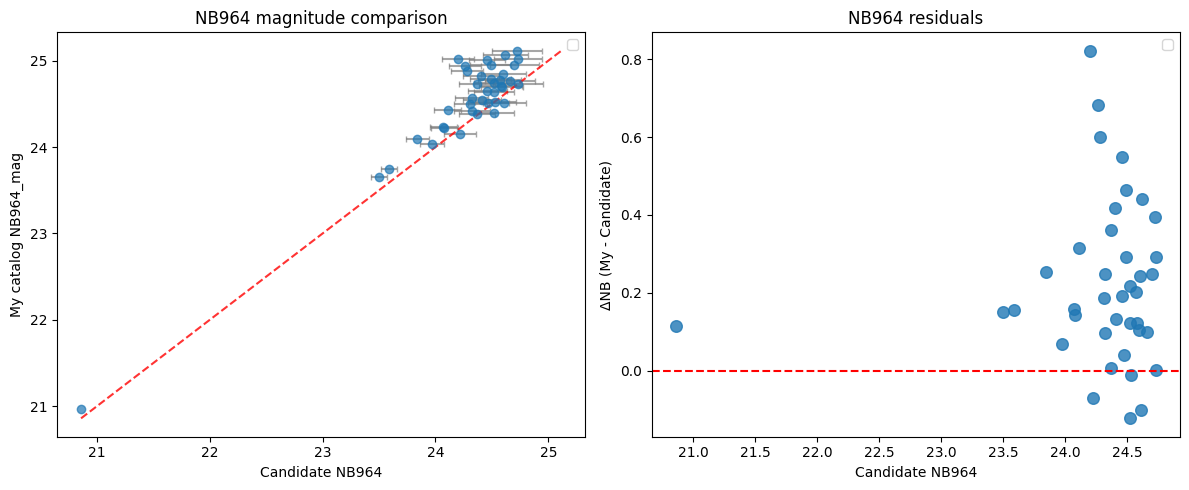


Saved comparison results to nb964_comparison_results.csv

Done.


In [85]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import os

# ----------------------------
# Load your NB964 photometry results
# ----------------------------
nb_path = "/Users/aishwarya/Documents/Lyman_alpha/n964_unpack/simple_results.csv"
nbdata = pd.read_csv(nb_path)

print(f"Loaded NB964 photometry: {nbdata.shape[0]} rows, {nbdata.shape[1]} columns")

# ----------------------------
# Clean and prepare catalog
# ----------------------------
# Check if 'target' column exists, otherwise generate sequential names
if 'target' in nbdata.columns:
    names = nbdata['target']
else:
    names = ["NB" + str(i+1) for i in range(len(nbdata))]

mycat = pd.DataFrame({
    "Name": names,
    "ra": nbdata["RA"],
    "dec": nbdata["Dec"],  # This may already be negative
    "mag_nb": nbdata["mag_AB"],
    "mag_err": nbdata.get("mag_err", np.nan),
    "flux": nbdata.get("flux_counts", np.nan),
    "zp":   28.85742
})

out_csv = "nb964_mycat.csv"
mycat.to_csv(out_csv, index=False)
print(f"\nSaved cleaned NB964 catalog to {os.path.abspath(out_csv)}")

# ----------------------------
# Load candidates catalog
# ----------------------------
candidates_path = "/Users/aishwarya/Downloads/candidates.csv"
print(f"\nLoading candidates from {candidates_path}")

candidates = pd.read_csv(candidates_path, comment="#", sep=",", header=None)
candidates.columns = ['Name','RA','Dec','z_band','z_band_err','NB964_band','NB964_err']

# Convert numeric columns
for col in ['z_band','z_band_err','NB964_band','NB964_err']:
    candidates[col] = pd.to_numeric(candidates[col], errors='coerce')

# Convert candidate coordinates to decimal degrees (assuming RA in decimal hours or degrees)
try:
    cand_coords = SkyCoord(candidates['RA'], candidates['Dec'], unit=(u.hourangle, u.deg))
    candidates['ra_deg'] = cand_coords.ra.deg
    candidates['dec_deg'] = -cand_coords.dec.deg  # Flip to negative if necessary
    print("Converted candidate coordinates and flipped Dec sign to negative")
except Exception as e:
    print(f"Coordinate conversion error, assuming RA/Dec are already decimal degrees: {e}")
    candidates['ra_deg'] = pd.to_numeric(candidates['RA'], errors='coerce')
    candidates['dec_deg'] = -pd.to_numeric(candidates['Dec'], errors='coerce')

# ----------------------------
# Direct comparison by coordinate matching
# ----------------------------
print(f"\nMy catalog: {len(mycat)} sources")
print(f"Candidates catalog: {len(candidates)} sources")

# Print RA/Dec ranges
print(f"My catalog RA range: {mycat['ra'].min():.6f} to {mycat['ra'].max():.6f}")
print(f"My catalog Dec range: {mycat['dec'].min():.6f} to {mycat['dec'].max():.6f}")
print(f"Candidates RA range: {candidates['ra_deg'].min():.6f} to {candidates['ra_deg'].max():.6f}")
print(f"Candidates Dec range: {candidates['dec_deg'].min():.6f} to {candidates['dec_deg'].max():.6f}")

# Match by coordinates
matched_pairs = []
tolerance_deg = 0.0001  # ~0.36 arcsec

for i, my_row in mycat.iterrows():
    my_ra = my_row['ra']
    my_dec = my_row['dec']
    
    cand_match = candidates[
        (np.abs(candidates['ra_deg'] - my_ra) < tolerance_deg) &
        (np.abs(candidates['dec_deg'] - my_dec) < tolerance_deg)
    ]
    
    if len(cand_match) > 0:
        matched_pairs.append({
            'my_name': my_row['Name'],
            'cand_name': cand_match.iloc[0]['Name'],
            'my_ra': my_ra,
            'my_dec': my_dec,
            'cand_ra': cand_match.iloc[0]['ra_deg'],
            'cand_dec': cand_match.iloc[0]['dec_deg'],
            'my_nb': my_row['mag_nb'],
            'my_nb_err': my_row['mag_err'],
            'cand_nb': cand_match.iloc[0]['NB964_band'],
            'cand_nb_err': cand_match.iloc[0]['NB964_err'],
            'my_flux': my_row['flux']
        })

print(f"\nFound {len(matched_pairs)} matches after correcting Dec sign!")

if len(matched_pairs) > 0:
    comparison_df = pd.DataFrame(matched_pairs)
    comparison_df['delta_nb'] = comparison_df['my_nb'] - comparison_df['cand_nb']
    
    print("\nComparison results:")
    print(comparison_df[['my_name', 'cand_name', 'my_nb', 'cand_nb', 'delta_nb']].to_string(index=False))
    
    print(f"\nΔNB statistics:")
    print(f"  Mean: {comparison_df['delta_nb'].mean():.3f}")
    print(f"  Std: {comparison_df['delta_nb'].std():.3f}")
    print(f"  Min: {comparison_df['delta_nb'].min():.3f}")
    print(f"  Max: {comparison_df['delta_nb'].max():.3f}")
    print(f"  N: {len(comparison_df)}")
    
    # Plots with error bars
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.errorbar(comparison_df['cand_nb'], comparison_df['my_nb'],
                 yerr=comparison_df['my_nb_err'], xerr=comparison_df['cand_nb_err'],
                 fmt='o', alpha=0.7, ecolor='gray', capsize=2)
    minv = min(comparison_df['cand_nb'].min(), comparison_df['my_nb'].min())
    maxv = max(comparison_df['cand_nb'].max(), comparison_df['my_nb'].max())
    plt.plot([minv, maxv], [minv, maxv], 'r--', alpha=0.8)
    plt.xlabel("Candidate NB964")
    plt.ylabel("My catalog NB964_mag")
    plt.title("NB964 magnitude comparison")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.scatter(comparison_df['cand_nb'], comparison_df['delta_nb'], s=70, alpha=0.8)
    plt.axhline(0, color='r', ls='--')
    plt.xlabel("Candidate NB964")
    plt.ylabel("ΔNB (My - Candidate)")
    plt.title("NB964 residuals")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Save comparison results
    comp_csv = "nb964_comparison_results.csv"
    comparison_df.to_csv(comp_csv, index=False)
    print(f"\nSaved comparison results to {comp_csv}")

else:
    print("No direct matches found, performing broad cross-match...")

    c_my = SkyCoord(ra=mycat['ra'].values*u.deg, dec=mycat['dec'].values*u.deg)
    c_cand = SkyCoord(ra=candidates['ra_deg'].values*u.deg, dec=candidates['dec_deg'].values*u.deg)
    idx, sep2d, _ = c_my.match_to_catalog_sky(c_cand)
    
    sep_arcsec = sep2d.arcsecond
    print(f"\nCross-match separation statistics:")
    print(f"  Min: {sep_arcsec.min():.3f} arcsec")
    print(f"  Max: {sep_arcsec.max():.3f} arcsec")
    print(f"  Mean: {sep_arcsec.mean():.3f} arcsec")
    
    closest_idx = np.argsort(sep_arcsec)[:5]
    print(f"\nClosest 5 matches:")
    for i in closest_idx:
        print(f"  {mycat.iloc[i]['Name']} -> {candidates.iloc[idx[i]]['Name']}: {sep_arcsec[i]:.3f} arcsec")

print("\nDone.")


In [ ]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip, mad_std

# --- Configuration ---
ZP_AB = 30.506  # AB zero point (fixed)
aperture_radii = [2.5, 3.0, 3.5]  # pixel radii to try
annulus_radii = [(6.0, 10.0), (8.0, 12.0)]

# --- Input files & targets ---
fits_files = [
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile11.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile12.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile13.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile21.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile22.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile23.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile31.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile32.fits",
    "/Users/aishwarya/Documents/Lyman_alpha/z_unpack/c4d_210831_053503_osj_z_vik2/c4d_210831_053503_osj_z_vik2_tile33.fits",
]

# Example target list (same as your original). Replace or extend as needed:
input_targets = [
    ("23:48:33.33", "-30:54:10.23"), ("23:50:39.46", "-31:47:26.41"),
    # … (rest of your list) …
    ("23:48:43.58", "-29:53:13.94"),
]
coords = SkyCoord([ra for ra, _ in input_targets],
                  [dec for _, dec in input_targets],
                  unit=(u.hourangle, u.deg))

# --- Helper functions ---

def estimate_background(data):
    """Return background-subtracted data and background RMS."""
    sigma_clip = SigmaClip(sigma=2.5, maxiters=5)
    bkg = Background2D(data, (512, 512), filter_size=(7, 7),
                       sigma_clip=sigma_clip, bkg_estimator=MedianBackground(),
                       exclude_percentile=5.0)
    data_sub = data - bkg.background
    return data_sub, bkg.background_rms

def photometry_for_coords(data_sub, bkg_rms, positions, exptime):
    """Perform aperture photometry for each radius/annulus, return list of results dicts."""
    results = []
    for r in aperture_radii:
        for (rin, rout) in annulus_radii:
            # require annulus to enclose background zone
            if rin <= r + 2:
                continue
            apertures = CircularAperture(positions, r=r)
            annulus = CircularAnnulus(positions, r_in=rin, r_out=rout)
            phot = aperture_photometry(data_sub, apertures)
            bkg_phot = aperture_photometry(data_sub, annulus)
            
            bkg_mean = bkg_phot['aperture_sum'] / annulus.area
            flux_net = phot['aperture_sum'] - bkg_mean * apertures.area
            # error: photon + background terms
            flux_err = np.sqrt(phot['aperture_sum']
                               + apertures.area * bkg_rms**2
                               + (apertures.area**2 / annulus.area) * bkg_rms**2)
            
            for i, pos in enumerate(positions):
                flux = flux_net[i]
                ferr = flux_err[i]
                snr = abs(flux) / ferr if ferr > 0 else 0.0
                if exptime > 0:
                    flux_sec = flux / exptime
                    if flux_sec > 0:
                        mag = ZP_AB - 2.5 * np.log10(flux_sec)
                        mag_err = 1.0857 * (ferr / abs(flux)) if flux != 0 else np.nan
                    else:
                        mag, mag_err = np.nan, np.nan
                else:
                    flux_sec, mag, mag_err = np.nan, np.nan, np.nan
                
                results.append({
                    'index': i,
                    'aperture_radius': r,
                    'ann_in': rin,
                    'ann_out': rout,
                    'flux': flux,
                    'flux_err': ferr,
                    'SNR': snr,
                    'mag_AB': mag,
                    'mag_err': mag_err
                })
    return results

def run_photometry(fits_files, coords):
    """Main loop over FITS files, aggregate best results over all coordinates."""
    n_targets = len(coords)
    best = [None] * n_targets  # store best measurement per target
    detailed = []
    
    for fname in fits_files:
        with fits.open(fname) as hdul:
            hdu = next((h for h in hdul if h.data is not None and h.data.ndim == 2), None)
            if hdu is None:
                continue
            data = hdu.data.astype(float)
            header = hdu.header
            exptime = header.get('EXPTIME', header.get('EXPOSURE', 1.0))
            wcs = WCS(header)
            
            # world → pixel
            x_all, y_all = wcs.world_to_pixel(coords)
            ny, nx = data.shape
            buffer = 30
            inside = (x_all > buffer) & (x_all < nx - buffer) & (y_all > buffer) & (y_all < ny - buffer)
            idxs = np.where(inside)[0]
            if len(idxs) == 0:
                continue
            
            data_sub, bkg_rms = estimate_background(data)
            positions = np.transpose([x_all[idxs], y_all[idxs]])
            
            # photometry for those positions
            res = photometry_for_coords(data_sub, bkg_rms, positions, exptime)
            for rec in res:
                rec2 = rec.copy()
                rec2.update({
                    'filename': os.path.basename(fname),
                    'target_idx': idxs[rec['index']],
                    'x_pix': x_all[idxs][rec['index']],
                    'y_pix': y_all[idxs][rec['index']],
                    'EXPTIME': exptime
                })
                detailed.append(rec2)
                
                # update best if better SNR
                ti = rec2['target_idx']
                prev = best[ti]
                if (prev is None) or (rec2['SNR'] > prev['SNR']):
                    best[ti] = rec2
    
    return detailed, best

# --- Execution ---

detailed_list, best_list = run_photometry(fits_files, coords)

# Convert to DataFrames
df_all = pd.DataFrame(detailed_list)
df_best = pd.DataFrame([b for b in best_list if b is not None])

# Add RA/Dec and target labels
labels = [f"Target-{i+1}" for i in range(len(coords))]
ra_list = coords.ra.deg
dec_list = coords.dec.deg
df_best['target'] = df_best['target_idx'].apply(lambda i: labels[i])
df_best['RA'] = df_best['target_idx'].apply(lambda i: ra_list[i])
df_best['Dec'] = df_best['target_idx'].apply(lambda i: dec_list[i])

# Save outputs
out_dir = os.path.dirname(fits_files[0])
df_best.to_csv(os.path.join(out_dir, "best_photometry.csv"), index=False)
df_all.to_csv(os.path.join(out_dir, "all_photometry.csv"), index=False)

# (Optional) Print a summary
print("Photometry done.")
print(f"Targets with detection: {len(df_best)}/{len(coords)}")
print("Example of best photometry results:")
print(df_best.head())
